# 🌀 Vortex-Tube Helicity Study — *Prediction accuracy ≠ explanation fidelity*

**One notebook, end-to-end, resumable.** It implements the full workflow for your 2 500-row × 35-column vortex-tube dataset (12 inputs → 23 outputs):

```
Data / provenance audit → 12 inputs → 23 outputs → 3 primary proxy outputs (Vorticity · Helicity · Q)
→ random 1500 / 500 / 500 split (train / calibration / test) → 5-fold CV on train
→ 5 regression baselines → select Quadratic Ridge
    ├─ Prediction evaluation
    ├─ Uncertainty analysis  → split-conformal intervals
    └─ Explanation audit     → exact SHAP → permutation → derivative fidelity
                               → Mach-sensitivity diagnosis → 3-input ablation
→ High-swirl extrapolation test → Polynomial-vs-tree comparison → FINAL FINDING
```

### How to use
1. **Runtime ▸ Run all** (Colab will ask you to mount Google Drive and to **upload the CSV** once).
2. Every stage stores its result in **Google Drive** (`MyDrive/vortex_tube_helicity/cache`). If the runtime disconnects, just **Run all again** — finished stages are loaded from Drive in seconds and only unfinished stages are recomputed.
3. Final tables, figures, models, the audit and the report are saved in Drive (`…/results`, `…/models`) **and** zipped and downloaded automatically at the end (`vortex_tube_results.zip`).

### Knobs
All settings are in the *Configuration* block of the next cell (seed, split sizes, conformal level, ablation inputs, …). `FORCE_RERUN = ["deriv"]` recomputes that stage **and everything after it**; `RESET_ALL = True` wipes all cached results.

>


## 1 · Setup — imports, Drive mount, configuration
Mounts Google Drive, creates the project folder tree and defines the resume machinery. **Edit the configuration block here** if you want different settings.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 1 · SETUP — imports · Google-Drive mount · configuration · resume helpers
# ═══════════════════════════════════════════════════════════════════════════
import os, sys, re, json, time, math, shutil, hashlib, zipfile, warnings, platform, itertools
from pathlib import Path
from datetime import datetime
import numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown
from scipy import stats
import sklearn
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
warnings.filterwarnings("ignore")

# ───────────────────────────── CONFIGURATION ────────────────────────────────
PROJECT_DIR_NAME = "vortex_tube_helicity"   # folder created in MyDrive
SEED             = 42
N_INPUTS         = 12                        # first 12 columns = inputs, rest = outputs
FRAC_TRAIN, FRAC_CAL = 0.60, 0.20            # 2500 rows → 1500 / 500 / 500
CV_FOLDS         = 5
SELECTED_MODEL   = "Quadratic Ridge"         # must be "Quadratic Ridge" or "Linear Ridge" (exact SHAP)
ALPHA_CONF       = 0.10                      # conformal miscoverage → 90 % intervals
PERM_REPEATS     = 20                        # permutation-importance repeats
FD_STEP          = 0.25                      # finite-difference half-step, in input-std units
KNN_K            = 300                       # neighbours for the local-linear reference derivative
KNN_RIDGE        = 0.01                      # relative ridge in the local fit
FID_SNR_MIN      = 2.0                       # reference derivative must be resolvable (|g|/SE ≥ this)
FID_NMAE_GOOD, FID_NMAE_FAIR, FID_SIGN_GOOD = 0.35, 0.60, 0.85
N_BOOT           = 40                        # bootstrap refits for the Mach-stability diagnosis
N_ABLATION       = 3                         # number of inputs kept in the ablation
ABLATION_FEATURES = None                     # e.g. ["Swirl Number","Reynolds Number","Mach Number"]; None = auto (top-3 SHAP on calibration set)
SWIRL_Q          = 0.70                      # train only on swirl ≤ this quantile; test on the rest
EXTRAP_MODELS    = ["Quadratic Ridge", "Linear Ridge", "Random Forest", "Gradient Boosting"]
UPLOAD_NEW       = False                     # True → force a fresh CSV upload prompt
RESET_ALL        = False                     # True → delete all cached results and start over
FORCE_RERUN      = []                        # e.g. ["deriv"] → recompute that stage and all later ones
# ────────────────────────────────────────────────────────────────────────────

STAGES = ["audit","split","cv","final","conformal","shap","perm","deriv","mach","ablation","extrap","polytree","report"]

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive, files
    drive.mount("/content/drive")
    BASE = Path("/content/drive/MyDrive") / PROJECT_DIR_NAME
else:                                        # local / CI fallback
    BASE = Path(os.environ.get("VORTEX_BASE", "./" + PROJECT_DIR_NAME)).resolve()

DATA_DIR, CACHE_DIR = BASE/"data", BASE/"cache"
TAB_DIR, FIG_DIR    = BASE/"results"/"tables", BASE/"results"/"figures"
MODEL_DIR, REP_DIR  = BASE/"models", BASE/"results"/"report"

if RESET_ALL:
    for d in (CACHE_DIR, TAB_DIR, FIG_DIR, MODEL_DIR, REP_DIR):
        shutil.rmtree(d, ignore_errors=True)
for d in (DATA_DIR, CACHE_DIR, TAB_DIR, FIG_DIR, MODEL_DIR, REP_DIR):
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi":110, "savefig.dpi":150, "axes.grid":True, "grid.alpha":0.3,
                     "axes.spines.top":False, "axes.spines.right":False, "font.size":10})
T0 = time.time()
rng_global = np.random.default_rng(SEED)

def log(msg):
    line = f"[{datetime.now():%H:%M:%S}  +{time.time()-T0:6.0f}s] {msg}"
    print(line)
    with open(REP_DIR/"run_log.txt", "a") as fh: fh.write(line + "\n")

# ── resume helpers ──────────────────────────────────────────────────────────
def _forced(name):
    idx = [STAGES.index(s) for s in FORCE_RERUN if s in STAGES]
    return bool(idx) and STAGES.index(name) >= min(idx)
def stage_done(name):
    return (CACHE_DIR/f"{name}.joblib").exists() and not _forced(name)
def save_stage(name, obj):
    tmp = CACHE_DIR/f".{name}.tmp"
    joblib.dump(obj, tmp, compress=3)
    os.replace(tmp, CACHE_DIR/f"{name}.joblib")          # atomic → safe if Drive disconnects
    log(f"💾 stage '{name}' saved to Drive cache")
def load_stage(name):
    log(f"♻️  stage '{name}' resumed from Drive cache")
    return joblib.load(CACHE_DIR/f"{name}.joblib")
def save_table(df, name, index=False):
    df.to_csv(TAB_DIR/f"{name}.csv", index=index); return df
def savefig(fig, name):
    fig.tight_layout(); fig.savefig(FIG_DIR/f"{name}.png", bbox_inches="tight"); plt.show(); plt.close(fig)
def show_saved(*names):
    for n in names:
        p = FIG_DIR/f"{n}.png"
        if p.exists(): display(Image(filename=str(p)))

print(f"scikit-learn {sklearn.__version__} · numpy {np.__version__} · pandas {pd.__version__}")
print(f"📁 Project folder: {BASE}")
done = [s for s in STAGES if stage_done(s)]
print("✅ Stages already completed (will be resumed):", done if done else "none — fresh run")


Mounted at /content/drive
scikit-learn 1.6.1 · numpy 2.1.3 · pandas 2.2.3
📁 Project folder: /content/drive/MyDrive/vortex_tube_helicity
✅ Stages already completed (will be resumed): none — fresh run


## 2 · Helper library
Polynomial-ridge model class (exposes its coefficients), metrics, split-conformal quantile, **closed-form exact SHAP** (with a brute-force verifier), finite-difference gradients and the local-linear reference derivative.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 2 · HELPER LIBRARY — models · metrics · conformal · exact SHAP · derivatives
# ═══════════════════════════════════════════════════════════════════════════
def norm(s): return re.sub(r"[^a-z0-9]", "", str(s).lower())
def short(s): return re.sub(r"\s*\(.*\)\s*$", "", str(s)).strip()

class PolyRidge(RegressorMixin, BaseEstimator):
    """Standardise → polynomial expansion (degree 1 or 2) → RidgeCV (alpha by efficient LOO-CV).
    Keeps everything needed for closed-form SHAP: coefficients in standardised-input space."""
    def __init__(self, degree=2, alphas=tuple(np.logspace(-3, 3, 25))):
        self.degree = degree; self.alphas = alphas
    def _z(self, X):
        return (np.asarray(X, float) - self.x_mean_) / self.x_std_
    def fit(self, X, y):
        X = np.asarray(X, float); y = np.asarray(y, float).ravel()
        self.x_mean_ = X.mean(0); self.x_std_ = X.std(0); self.x_std_[self.x_std_ == 0] = 1.0
        self.y_mean_ = float(y.mean()); self.y_std_ = float(y.std()) or 1.0
        self.poly_ = PolynomialFeatures(self.degree, include_bias=False)
        P = self.poly_.fit_transform(self._z(X))
        self.p_std_ = P.std(0); self.p_std_[self.p_std_ == 0] = 1.0
        rcv = RidgeCV(alphas=np.asarray(self.alphas)).fit(P / self.p_std_, (y - self.y_mean_) / self.y_std_)
        self.alpha_ = float(rcv.alpha_)
        self.coef_z_ = rcv.coef_ / self.p_std_          # coefficients on raw polynomial terms of z (y in std units)
        self.intercept_z_ = float(rcv.intercept_)
        return self
    def predict(self, X):
        P = self.poly_.transform(self._z(X))
        return (P @ self.coef_z_ + self.intercept_z_) * self.y_std_ + self.y_mean_

MODEL_NAMES = ["Linear Ridge", "Quadratic Ridge", "Random Forest", "Gradient Boosting", "MLP"]
def make_model(name, seed=SEED):
    if name == "Linear Ridge":     return PolyRidge(degree=1)
    if name == "Quadratic Ridge":  return PolyRidge(degree=2)
    if name == "Random Forest":    return RandomForestRegressor(n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=seed)
    if name == "Gradient Boosting":return HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, l2_regularization=1.0, random_state=seed)
    if name == "MLP":
        return TransformedTargetRegressor(
            regressor=make_pipeline(StandardScaler(), MLPRegressor(hidden_layer_sizes=(64, 64), alpha=1e-3, early_stopping=True,
                                    n_iter_no_change=30, max_iter=1500, random_state=seed)),
            transformer=StandardScaler())
    raise ValueError(name)

def reg_metrics(y, p):
    y, p = np.asarray(y, float), np.asarray(p, float)
    rmse = float(np.sqrt(mean_squared_error(y, p)))
    return dict(R2=float(r2_score(y, p)), RMSE=rmse, MAE=float(mean_absolute_error(y, p)),
                nRMSE=rmse / float(np.std(y)), Bias=float(np.mean(p - y)))

# ── split-conformal ─────────────────────────────────────────────────────────
def conformal_q(abs_res, alpha):
    n = len(abs_res); level = min(1.0, math.ceil((n + 1) * (1 - alpha)) / n)
    return float(np.quantile(abs_res, level, method="higher"))

# ── exact Shapley values for a degree ≤ 2 polynomial model (interventional, empirical background) ─────
def quad_shap(model, X, Xbg):
    """Closed-form exact SHAP.  f(z)=b+Σ a_i z_i+Σ c_ij z_i z_j  ⇒  each term is a 1- or 2-player game
    whose Shapley value is available analytically (others are dummy players).  Background = Xbg (empirical)."""
    Z, Zb = model._z(X), model._z(Xbg)
    n, d = Z.shape
    m = Zb.mean(0); M2 = Zb.T @ Zb / len(Zb)
    phi = np.zeros((n, d))
    for pw, c in zip(model.poly_.powers_, model.coef_z_):
        nz = np.flatnonzero(pw)
        if len(nz) == 1 and pw[nz[0]] == 1:
            i = nz[0]; phi[:, i] += c * (Z[:, i] - m[i])
        elif len(nz) == 1 and pw[nz[0]] == 2:
            i = nz[0]; phi[:, i] += c * (Z[:, i] ** 2 - M2[i, i])
        elif len(nz) == 2:
            i, j = nz
            phi[:, i] += c * 0.5 * ((Z[:, i]*Z[:, j] - Z[:, j]*m[i]) + (Z[:, i]*m[j] - M2[i, j]))
            phi[:, j] += c * 0.5 * ((Z[:, i]*Z[:, j] - Z[:, i]*m[j]) + (Z[:, j]*m[i] - M2[i, j]))
        else:
            raise ValueError("quad_shap supports degree ≤ 2 only")
    return phi * model.y_std_, float(model.predict(Xbg).mean())

def brute_shapley(predict, x, Xbg):
    """Definition-level Shapley (all 2^d coalitions) — used only to VERIFY quad_shap on one sample."""
    d = len(x); nb = len(Xbg); N = 1 << d
    bits = ((np.arange(N)[:, None] >> np.arange(d)) & 1).astype(bool)
    v = np.zeros(N)
    for s in range(0, N, 128):
        b = bits[s:s+128]
        Xmix = np.where(b[:, None, :], x[None, None, :], Xbg[None, :, :]).reshape(-1, d)
        v[s:s+128] = predict(Xmix).reshape(len(b), nb).mean(1)
    pop = bits.sum(1); fact = [math.factorial(k) for k in range(d + 1)]
    w = np.array([fact[k] * fact[d - k - 1] / fact[d] for k in range(d)])
    masks = np.arange(N); phi = np.zeros(d)
    for i in range(d):
        without = masks[~bits[:, i]]
        phi[i] = np.sum(w[pop[without]] * (v[without | (1 << i)] - v[without]))
    return phi, v[0]

# ── derivatives ─────────────────────────────────────────────────────────────
def fd_grad(predict, X, x_std, h=FD_STEP):
    """Central finite-difference gradient; unit = target-units per +1 input-std."""
    X = np.asarray(X, float); G = np.zeros_like(X)
    for j in range(X.shape[1]):
        Xp, Xm = X.copy(), X.copy(); Xp[:, j] += h * x_std[j]; Xm[:, j] -= h * x_std[j]
        G[:, j] = (predict(Xp) - predict(Xm)) / (2 * h)
    return G

def local_linear_grad(Zref, yref, Zq, k=KNN_K, lam=KNN_RIDGE):
    """Data-driven reference derivative: tricube-weighted local-linear ridge fit around each query point.
    Returns slopes (target-units per +1 input-std) and their standard errors."""
    n, d = Zq.shape
    nn = NearestNeighbors(n_neighbors=min(k, len(Zref))).fit(Zref)
    dist, idx = nn.kneighbors(Zq)
    G = np.zeros((n, d)); SE = np.zeros((n, d))
    for q in range(n):
        h = dist[q, -1] * 1.0001 + 1e-12
        w = (1 - (dist[q] / h) ** 3) ** 3
        A = Zref[idx[q]] - Zq[q]; yy = yref[idx[q]]; sw = w.sum()
        Ac = A - (w[:, None] * A).sum(0) / sw; yc = yy - (w * yy).sum() / sw
        AtW = Ac.T * w; M = AtW @ Ac
        Minv = np.linalg.inv(M + lam * np.trace(M) / d * np.eye(d))
        beta = Minv @ (AtW @ yc)
        res = yc - Ac @ beta
        keff = sw ** 2 / (w ** 2).sum()
        sigma2 = (w * res ** 2).sum() / sw * keff / max(keff - d - 1, 1.0)
        G[q] = beta; SE[q] = np.sqrt(np.maximum(np.diag(Minv @ M @ Minv) * sigma2, 0))
    return G, SE

def fidelity_table(G_model, G_ref, SE_ref, feats):
    rows = []
    for j, f in enumerate(feats):
        g, r = G_model[:, j], G_ref[:, j]
        snr = float(np.median(np.abs(r) / (SE_ref[:, j] + 1e-12)))
        corr = float(np.corrcoef(g, r)[0, 1]) if g.std() > 0 and r.std() > 0 else np.nan
        sign = float(np.mean(np.sign(g) == np.sign(r)))
        nmae = float(np.mean(np.abs(g - r)) / (np.mean(np.abs(r)) + 1e-12))
        resolvable = snr >= FID_SNR_MIN
        if not resolvable:                                   grade = "unresolved"
        elif nmae <= FID_NMAE_GOOD and sign >= FID_SIGN_GOOD: grade = "good"
        elif nmae <= FID_NMAE_FAIR:                          grade = "fair"
        else:                                                grade = "poor"
        rows.append(dict(feature=f, ref_mean_abs=float(np.mean(np.abs(r))), ref_snr=snr, resolvable=resolvable,
                         corr=corr, sign_agree=sign, nMAE=nmae, slope_ratio=float(np.mean(g) / (np.mean(r) + 1e-12)), grade=grade))
    return pd.DataFrame(rows)

def fidelity_score(tbl):
    t = tbl[tbl.resolvable]
    return float(np.mean(np.clip(1 - t.nMAE.values, 0, 1))) if len(t) else np.nan

def md_table(d, fmt="{:.4g}"):
    d = d.copy()
    cols = [str(c) for c in d.columns]
    lines = ["| " + " | ".join(cols) + " |", "|" + "|".join(["---"] * len(cols)) + "|"]
    for row in d.itertuples(index=False):
        cells = [fmt.format(v) if isinstance(v, (float, np.floating)) else str(v) for v in row]
        lines.append("| " + " | ".join(cells) + " |")
    return "\n".join(lines)

print("✅ helpers defined")


✅ helpers defined


## 3 · Upload the dataset & data / provenance audit
A file dialog appears the **first time only**. The CSV is copied into Drive (`…/data/dataset.csv`), so after a runtime restart no re-upload is needed. A SHA-256 fingerprint guards against resuming stale results if you later swap the file.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 3a · UPLOAD + LOAD
# ═══════════════════════════════════════════════════════════════════════════
DATA_PATH = DATA_DIR / "dataset.csv"
if UPLOAD_NEW or not DATA_PATH.exists():
    if IN_COLAB:
        print("📂 Please upload your 2500-row helicity CSV (35 columns) …")
        up = files.upload()
        csvs = [k for k in up if k.lower().endswith(".csv")]
        if not csvs: raise RuntimeError("No .csv file was uploaded — re-run this cell and choose the dataset.")
        DATA_PATH.write_bytes(up[csvs[0]])
        print(f"✅ '{csvs[0]}' stored in Drive → {DATA_PATH}")
    else:
        src = os.environ.get("VORTEX_CSV")
        if not src: raise RuntimeError("Set env VORTEX_CSV to the dataset path when running outside Colab.")
        shutil.copy(src, DATA_PATH)
else:
    print(f"✅ Using dataset already stored in Drive: {DATA_PATH}   (set UPLOAD_NEW=True to replace it)")

df = pd.read_csv(DATA_PATH)
df.columns = [str(c).strip() for c in df.columns]
DATA_SHA = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
sha_file = CACHE_DIR / "data_sha256.txt"
if sha_file.exists() and sha_file.read_text().strip() != DATA_SHA:
    log("⚠️  Dataset changed since the cache was written → clearing cached stages.")
    for f in CACHE_DIR.glob("*.joblib"): f.unlink()
sha_file.write_text(DATA_SHA)

NORM2COL = {norm(c): c for c in df.columns}
def find(key):
    """Locate a column by (normalised) name or prefix, e.g. find('helicity') → 'Helicity(m/s2)'."""
    k = norm(key)
    if k in NORM2COL: return NORM2COL[k]
    for n_, c in NORM2COL.items():
        if n_.startswith(k): return c
    return None

INPUT_COLS  = list(df.columns[:N_INPUTS])
OUTPUT_COLS = list(df.columns[N_INPUTS:])
FEATS = [short(c) for c in INPUT_COLS]
TARGETS = {"Vorticity": find("vorticity"), "Helicity": find("helicity"), "Q-Criterion": find("qcriterion")}
assert all(TARGETS.values()), f"Could not locate all three primary targets in the header: {TARGETS}"
for c in df.columns: df[c] = pd.to_numeric(df[c], errors="coerce")

print(f"\nShape: {df.shape[0]} rows × {df.shape[1]} columns  |  SHA-256: {DATA_SHA[:16]}…")
print(f"Inputs  ({len(INPUT_COLS)}): {FEATS}")
print(f"Outputs ({len(OUTPUT_COLS)}): {[short(c) for c in OUTPUT_COLS]}")
print(f"Primary proxy targets: { {k: v for k, v in TARGETS.items()} }")
display(df.head(3))


📂 Please upload your 2500-row helicity CSV (35 columns) …


Saving dataset.csv to dataset.csv
✅ 'dataset.csv' stored in Drive → /content/drive/MyDrive/vortex_tube_helicity/data/dataset.csv

Shape: 2500 rows × 35 columns  |  SHA-256: c5b8a4bf16b51c89…
Inputs  (12): ['Inlet Pressure', 'Outlet Pressure', 'Cold Mass Fraction', 'Nozzle Diameter', 'Tube Diameter', 'Tube Length', 'L/D Ratio', 'Reynolds Number', 'Pressure Ratio', 'Mach Number', 'Swirl Number', 'Turbulence Intensity']
Outputs (23): ['Shock Angle', 'Shock Location', 'Maximum Mach', 'Minimum Pressure', 'Shock Length', 'Number of Shocks', 'Maximum Temperature', 'Cold Exit Temperature', 'Hot Exit Temperature', 'Pressure Drop', 'Entropy Generation', 'Shock Intensity', 'Vorticity', 'Helicity', 'Q-Criterion', 'Turbulent Kinetic Energy', 'Eddy Dissipation Rate', 'Circulation', 'Swirl Velocity', 'Axial Velocity', 'Tangential Velocity', 'Radial Pressure Gradient', 'Vortex Core Radius']
Primary proxy targets: {'Vorticity': 'Vorticity (1/s)', 'Helicity': 'Helicity(m/s2)', 'Q-Criterion': 'Q-Criterio

,Inlet Pressure (bar),Outlet Pressure (bar),Cold Mass Fraction,Nozzle Diameter (mm),Tube Diameter (mm),Tube Length (mm),L/D Ratio,Reynolds Number,Pressure Ratio,Mach Number,...,Helicity(m/s2),Q-Criterion(1/s2),Turbulent Kinetic Energy(m2/s2),Eddy Dissipation Rate(m2/s3),Circulation(m2/s),Swirl Velocity (m/s),Axial Velocity (m/s),Tangential Velocity (m/s),Radial Pressure Gradient (kPa/m),Vortex Core Radius (mm)
0,4.247,1.828,0.526,1.622,17.681,449.769,25.439,82920,2.324,0.702,...,320.985,33991.373,6.564,21.277,5.693,105.250,123.633,159.675,79.634,2.971
1,7.704,1.765,0.700,1.532,8.198,622.723,75.956,90285,4.366,0.911,...,191.843,33505.168,6.202,20.072,2.977,102.675,130.184,164.917,91.722,1.564
2,6.392,1.574,0.275,1.188,10.242,493.867,48.221,232562,4.062,0.893,...,324.561,40067.957,11.523,33.529,5.210,121.932,130.545,183.495,92.135,1.425


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 3b · DATA / PROVENANCE AUDIT
# ═══════════════════════════════════════════════════════════════════════════
RIG = dict(tube_ID_mm=19.0, tube_length_mm=380.0, n_nozzles=1, nozzle_w_mm=6.0, nozzle_h_mm=2.0,
           mdot_per_nozzle_kg_s=0.020, cold_diaphragm_mm=5.0, hot_valve_gap_mm=10.0,
           tc_bead_mm=3.0, tc_accuracy_pct=1.0, pressure_accuracy_pct=0.5, flow_accuracy_pct=3.0,
           cfd_codes="Ansys Fluent 22.1 · OpenFOAM v1902")

def vif_table(Xin, names):
    Z = (Xin - Xin.mean(0)) / Xin.std(0); out = []
    for j, nme in enumerate(names):
        others = np.delete(Z, j, axis=1)
        beta, *_ = np.linalg.lstsq(others, Z[:, j], rcond=None)
        r2 = 1 - np.sum((Z[:, j] - others @ beta) ** 2) / np.sum(Z[:, j] ** 2)
        out.append(dict(feature=nme, R2_vs_others=r2, VIF=1 / max(1 - r2, 1e-9)))
    return pd.DataFrame(out)

if stage_done("audit"):
    AUDIT = load_stage("audit")
    display(AUDIT["flags"]); display(AUDIT["rig_table"])
else:
    flags = []
    def flag(sev, area, msg): flags.append(dict(severity=sev, area=area, finding=msg))
    n, p = df.shape
    if (n, p) != (2500, 35): flag("WARN", "shape", f"Expected 2500×35 but found {n}×{p}.")
    else: flag("OK", "shape", "2500 rows × 35 columns as expected (12 inputs + 23 outputs).")

    n_miss = int(df.isna().sum().sum()); n_dup = int(df.duplicated().sum())
    const_cols = [c for c in df.columns if df[c].nunique() <= 1]
    flag("OK" if n_miss == 0 else "WARN", "integrity", f"{n_miss} missing/non-numeric cells.")
    flag("OK" if n_dup == 0 else "WARN", "integrity", f"{n_dup} duplicated rows.")
    flag("OK" if not const_cols else "WARN", "integrity", f"Constant columns: {const_cols or 'none'}.")

    # ── derived-variable consistency ──
    g = find
    if all(g(k) for k in ["tubelength", "tubediameter", "ldratio"]):
        e = np.abs(df[g("tubelength")] / df[g("tubediameter")] / df[g("ldratio")] - 1).max()
        flag("INFO", "redundancy", f"L/D Ratio ≈ Tube Length / Tube Diameter (max rel. error {e:.2%}) → the 3 columns are NOT independent inputs.")
    if all(g(k) for k in ["inletpressure", "outletpressure", "pressureratio"]):
        e = np.abs(df[g("inletpressure")] / df[g("outletpressure")] / df[g("pressureratio")] - 1).max()
        flag("INFO", "redundancy", f"Pressure Ratio ≈ Inlet / Outlet pressure (max rel. error {e:.2%}) → redundant with two other inputs.")
    if g("machnumber") and g("pressureratio"):
        c = df[g("machnumber")].corr(df[g("pressureratio")])
        flag("WARN" if abs(c) > 0.9 else "INFO", "collinearity",
             f"corr(Mach Number, Pressure Ratio) = {c:.3f} → Mach is almost a function of pressure ratio; its separate effect is barely identifiable.")
    if all(g(k) for k in ["inletpressure", "outletpressure", "pressuredrop"]):
        dp = (df[g("inletpressure")] - df[g("outletpressure")] - df[g("pressuredrop")]).abs()
        flag("WARN" if dp.mean() > 0.05 else "OK", "definition",
             f"'Pressure Drop' differs from Inlet−Outlet pressure by {dp.mean():.3f} bar on average (max {dp.max():.2f}) → definition of this column is undocumented.")
    if g("hotexittemperature") and g("coldexittemperature"):
        fr = (df[g("hotexittemperature")] > df[g("coldexittemperature")]).mean()
        flag("OK" if fr == 1 else "WARN", "physics", f"Hot-exit T > Cold-exit T in {fr:.1%} of rows.")
    if g("maximumtemperature") and g("hotexittemperature"):
        fr = (df[g("maximumtemperature")] >= df[g("hotexittemperature")]).mean()
        flag("OK" if fr > 0.99 else "WARN", "physics", f"'Maximum Temperature' ≥ Hot-exit T in only {fr:.1%} of rows → 'Maximum Temperature' is not a field maximum; clarify its definition.")
    if g("maximummach") and g("machnumber"):
        fr = (df[g("maximummach")] >= df[g("machnumber")]).mean()
        flag("OK" if fr > 0.99 else "WARN", "physics", f"'Maximum Mach' ≥ 'Mach Number' in {fr:.1%} of rows" + ("." if fr > 0.99 else f" → in {1-fr:.0%} of rows the 'maximum' is below the reported Mach number; the two columns use different (undocumented) definitions."))
        flag("INFO", "regime", f"{(df[g('maximummach')] > 1).mean():.1%} of rows have Maximum Mach > 1 (supersonic pockets / shocks).")
    if g("qcriterion") and g("vorticity"):
        c = np.corrcoef(df[g("qcriterion")], df[g("vorticity")] ** 2)[0, 1]
        flag("INFO", "targets", f"corr(Q-criterion, vorticity²) = {c:.3f}; corr(Vorticity, Helicity) = {df[TARGETS['Vorticity']].corr(df[TARGETS['Helicity']]):.3f} → the three 'primary' outputs are strongly related.")

    # ── sampling design: independent inputs uniform? ──
    base_keys = ["inletpressure", "outletpressure", "coldmassfraction", "nozzlediameter", "tubediameter", "tubelength", "reynoldsnumber", "swirlnumber", "turbulenceintensity"]
    ks = []
    for k in base_keys:
        c = g(k)
        if c: v = df[c].values; ks.append((c, stats.kstest(v, "uniform", args=(v.min(), v.max() - v.min())).pvalue))
    if ks:
        share = np.mean([pv > 0.05 for _, pv in ks])
        Xb = df[[c for c, _ in ks]].corr().values; off = np.abs(Xb[~np.eye(len(Xb), dtype=bool)]).max()
        flag("INFO", "provenance", f"{share:.0%} of the base inputs are statistically uniform (KS p>0.05) and mutually uncorrelated (max |r|={off:.2f}) → looks like a space-filling / random design-of-experiments, NOT measured operating points.")
    flag("WARN", "provenance", "No case ID, solver, mesh, run-time or uncertainty columns → provenance of Vorticity / Helicity / Q cannot be verified from the file alone. "
         "Your instruments (K-type TC, pressure transducer, flow controller) do not measure these quantities → treat them as simulation / proxy outputs.")

    # ── comparison with the physical rig ──
    a_rig = RIG["nozzle_w_mm"] * RIG["nozzle_h_mm"] / (math.pi / 4 * RIG["tube_ID_mm"] ** 2)
    d_eq = math.sqrt(4 * RIG["nozzle_w_mm"] * RIG["nozzle_h_mm"] / math.pi)
    d_h = 4 * RIG["nozzle_w_mm"] * RIG["nozzle_h_mm"] / (2 * (RIG["nozzle_w_mm"] + RIG["nozzle_h_mm"]))
    Dt, Ln, Dn = df[g("tubediameter")], df[g("tubelength")], df[g("nozzlediameter")]
    a_ds = (Dn / Dt) ** 2
    near = ((Dt / RIG["tube_ID_mm"] - 1).abs() <= 0.15) & ((Ln / RIG["tube_length_mm"] - 1).abs() <= 0.15) & ((a_ds / a_rig - 1).abs() <= 0.30)
    rig_rows = pd.DataFrame([
        ["Tube diameter (mm)", RIG["tube_ID_mm"], f"{Dt.min():.1f} – {Dt.max():.1f}", f"{((Dt / RIG['tube_ID_mm'] - 1).abs() <= 0.15).mean():.1%} within ±15 %"],
        ["Tube length (mm)", RIG["tube_length_mm"], f"{Ln.min():.0f} – {Ln.max():.0f}", f"{((Ln / RIG['tube_length_mm'] - 1).abs() <= 0.15).mean():.1%} within ±15 %"],
        ["L/D", RIG["tube_length_mm"] / RIG["tube_ID_mm"], f"{(Ln / Dt).min():.1f} – {(Ln / Dt).max():.1f}", f"{(((Ln / Dt) / 20 - 1).abs() <= 0.15).mean():.1%} within ±15 %"],
        ["Nozzle: 6×2 mm rectangle → equivalent circular Ø (mm)", round(d_eq, 2), f"{Dn.min():.2f} – {Dn.max():.2f}", "rig value lies OUTSIDE the dataset range" if d_eq > Dn.max() else "inside range"],
        ["Nozzle: hydraulic Ø (mm)", round(d_h, 2), f"{Dn.min():.2f} – {Dn.max():.2f}", "at the upper edge" if abs(d_h - Dn.max()) < 0.1 else "—"],
        ["Nozzle / tube area ratio (shape-independent)", round(a_rig, 4), f"{a_ds.min():.4f} – {a_ds.max():.4f}", f"{((a_ds / a_rig - 1).abs() <= 0.30).mean():.1%} within ±30 %"],
        ["Rows close to the rig on all 3 geometry criteria", "—", "—", f"{int(near.sum())} of {len(df)}"],
    ], columns=["Quantity", "Rig value", "Dataset range", "Overlap"])
    flag("WARN" if near.sum() < 0.02 * len(df) else "INFO", "rig-vs-data",
         f"Only {int(near.sum())} rows ({near.mean():.1%}) resemble your physical rig geometry (tube Ø19, L380, 6×2 nozzle). The dataset is a broad parametric envelope → conclusions are about the dataset, not directly about the rig.")
    flag("INFO", "rig-vs-data", "Rig thermocouples sit at the outlet plane: cold end on the axis, hot end at the periphery → 'exit temperature' columns are location-dependent point values, not mixed-mean values.")

    # ── collinearity & outliers ──
    Xin = df[INPUT_COLS].values.astype(float)
    vif = vif_table(Xin, FEATS)
    flag("WARN", "collinearity", "Highest-VIF inputs: " + ", ".join(f"{r.feature} ({r.VIF:.0f})" for r in vif.sort_values("VIF", ascending=False).head(4).itertuples()) + " → attributions/derivatives for these are ambiguous.")
    Cm = np.corrcoef(Xin.T); pairs = [(FEATS[i], FEATS[j], Cm[i, j]) for i in range(len(FEATS)) for j in range(i + 1, len(FEATS)) if abs(Cm[i, j]) > 0.7]
    pairs_df = pd.DataFrame(pairs, columns=["input_a", "input_b", "corr"]).sort_values("corr", key=abs, ascending=False)
    out_rows = []
    for lab, col in TARGETS.items():
        v = df[col]; z = (v - v.mean()) / v.std()
        out_rows.append(dict(target=lab, skew=v.skew(), excess_kurtosis=v.kurt(), n_abs_z_gt_4=int((z.abs() > 4).sum()), min=v.min(), max=v.max()))
    out_df = pd.DataFrame(out_rows)

    rng_tbl = df.describe().T[["min", "max", "mean", "std"]].assign(skew=df.skew()).reset_index().rename(columns={"index": "column"})
    flags_df = pd.DataFrame(flags)
    for t, nm in [(rng_tbl, "audit_column_ranges"), (vif, "audit_vif"), (pairs_df, "audit_collinear_pairs"), (rig_rows, "audit_rig_vs_dataset"), (flags_df, "audit_flags"), (out_df, "audit_target_distribution")]:
        save_table(t, nm)
    order = {"WARN": 0, "INFO": 1, "OK": 2}
    md = ["# Data / provenance audit", f"*Dataset fingerprint (SHA-256): `{DATA_SHA}`*", ""]
    md += [f"- **{r.severity}** · *{r.area}* — {r.finding}" for r in flags_df.sort_values("severity", key=lambda s: s.map(order)).itertuples()]
    md += ["", "## Rig vs dataset", md_table(rig_rows), "", "## Variance-inflation factors", md_table(vif),
           "", "## Target distributions", md_table(out_df)]
    (REP_DIR / "data_provenance_audit.md").write_text("\n".join(md))
    AUDIT = dict(flags=flags_df, rig_table=rig_rows, vif=vif, pairs=pairs_df, target_dist=out_df, n_near_rig=int(near.sum()))
    save_stage("audit", AUDIT)
    pd.set_option("display.max_colwidth", 220, "display.width", 250)
    display(flags_df); display(rig_rows); display(vif.round(2))


[18:13:08  +    60s] 💾 stage 'audit' saved to Drive cache


,severity,area,finding
0,OK,shape,2500 rows × 35 columns as expected (12 inputs + 23 outputs).
1,OK,integrity,0 missing/non-numeric cells.
2,OK,integrity,0 duplicated rows.
3,OK,integrity,Constant columns: none.
4,INFO,redundancy,L/D Ratio ≈ Tube Length / Tube Diameter (max rel. error 0.01%) → the 3 columns are NOT independent inputs.
5,INFO,redundancy,Pressure Ratio ≈ Inlet / Outlet pressure (max rel. error 0.08%) → redundant with two other inputs.
6,WARN,collinearity,"corr(Mach Number, Pressure Ratio) = 0.983 → Mach is almost a function of pressure ratio; its separate effect is barely identifiable."
7,WARN,definition,'Pressure Drop' differs from Inlet−Outlet pressure by 0.288 bar on average (max 0.71) → definition of this column is undocumented.
8,OK,physics,Hot-exit T > Cold-exit T in 100.0% of rows.
9,WARN,physics,'Maximum Temperature' ≥ Hot-exit T in only 1.2% of rows → 'Maximum Temperature' is not a field maximum; clarify its definition.


,Quantity,Rig value,Dataset range,Overlap
0,Tube diameter (mm),19.0,8.0 – 20.0,31.9% within ±15 %
1,Tube length (mm),380.0,100 – 800,15.9% within ±15 %
2,L/D,20.0,5.2 – 95.7,11.5% within ±15 %
3,Nozzle: 6×2 mm rectangle → equivalent circular Ø (mm),3.91,0.80 – 3.00,rig value lies OUTSIDE the dataset range
4,Nozzle: hydraulic Ø (mm),3.0,0.80 – 3.00,at the upper edge
5,Nozzle / tube area ratio (shape-independent),0.0423,0.0017 – 0.1339,18.7% within ±30 %
6,Rows close to the rig on all 3 geometry criteria,—,—,2 of 2500


,feature,R2_vs_others,VIF
0,Inlet Pressure,0.97,29.37
1,Outlet Pressure,0.90,9.91
2,Cold Mass Fraction,0.01,1.01
3,Nozzle Diameter,0.01,1.01
4,Tube Diameter,0.79,4.72
5,Tube Length,0.92,11.82
6,L/D Ratio,0.94,15.58
7,Reynolds Number,0.00,1.00
8,Pressure Ratio,0.98,40.50
9,Mach Number,0.97,34.53


## 4 · Primary proxy targets & random partition
Vorticity · Helicity · Q-criterion are modelled from the 12 inputs. Random split **1500 train / 500 calibration / 500 test** (calibration is used only for conformal intervals and ablation-input selection).

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 4 · TARGET SELECTION + RANDOM PARTITION  (1500 train / 500 calibration / 500 test)
# ═══════════════════════════════════════════════════════════════════════════
used = INPUT_COLS + list(TARGETS.values())
n_bad = int(df[used].isna().any(axis=1).sum())
if n_bad: log(f"⚠️ dropping {n_bad} rows with NaN in used columns")
DF = df.dropna(subset=used).reset_index(drop=True)
N = len(DF)
X = DF[INPUT_COLS].values.astype(float)
Y = {lab: DF[col].values.astype(float) for lab, col in TARGETS.items()}
LABS = list(TARGETS)

if stage_done("split"):
    SPLIT = load_stage("split")
else:
    n_tr, n_cal = int(round(FRAC_TRAIN * N)), int(round(FRAC_CAL * N))
    all_idx = np.arange(N)
    tr, rest = train_test_split(all_idx, train_size=n_tr, random_state=SEED, shuffle=True)
    cal, te = train_test_split(rest, train_size=n_cal, random_state=SEED, shuffle=True)
    ks_p = [stats.ks_2samp(X[tr, j], X[te, j]).pvalue for j in range(X.shape[1])]
    SPLIT = dict(train=np.sort(tr), cal=np.sort(cal), test=np.sort(te), min_ks_p=float(np.min(ks_p)))
    pd.DataFrame({"row": np.r_[SPLIT["train"], SPLIT["cal"], SPLIT["test"]],
                  "partition": ["train"] * len(tr) + ["calibration"] * len(cal) + ["test"] * len(te)}).to_csv(TAB_DIR / "split_indices.csv", index=False)
    save_stage("split", SPLIT)

idx_tr, idx_cal, idx_te = SPLIT["train"], SPLIT["cal"], SPLIT["test"]
Xtr, Xcal, Xte = X[idx_tr], X[idx_cal], X[idx_te]
x_mean, x_std = Xtr.mean(0), Xtr.std(0)
SWIRL_COL = find("swirlnumber"); SWIRL_J = INPUT_COLS.index(SWIRL_COL)
MACH_COL = find("machnumber"); MACH_J = INPUT_COLS.index(MACH_COL) if MACH_COL in INPUT_COLS else None
assert SELECTED_MODEL in ("Quadratic Ridge", "Linear Ridge"), "Exact SHAP requires a polynomial ridge model."
print(f"Rows used: {N} → train {len(idx_tr)} · calibration {len(idx_cal)} · test {len(idx_te)}  (seed {SEED})")
_p_adj = min(1.0, SPLIT["min_ks_p"] * X.shape[1])
print(f"Partition balance: smallest train-vs-test KS p-value over {X.shape[1]} inputs = {SPLIT['min_ks_p']:.3f} (Bonferroni-adjusted {_p_adj:.2f}; > 0.05 ⇒ no evidence the partitions differ)")
print("Primary targets:", {k: short(v) for k, v in TARGETS.items()})


[18:13:40  +    92s] 💾 stage 'split' saved to Drive cache
Rows used: 2500 → train 1500 · calibration 500 · test 500  (seed 42)
Partition balance: smallest train-vs-test KS p-value over 12 inputs = 0.009 (Bonferroni-adjusted 0.11; > 0.05 ⇒ no evidence the partitions differ)
Primary targets: {'Vorticity': 'Vorticity', 'Helicity': 'Helicity', 'Q-Criterion': 'Q-Criterion'}


## 5 · Five regression baselines — 5-fold CV on training data
Linear Ridge · Quadratic Ridge · Random Forest · Gradient Boosting · MLP.

[18:13:46  +    98s] CV  Vorticity    Linear Ridge       done in   0.1s
[18:13:48  +   100s] CV  Vorticity    Quadratic Ridge    done in   1.6s
[18:14:02  +   114s] CV  Vorticity    Random Forest      done in  14.4s
[18:14:07  +   119s] CV  Vorticity    Gradient Boosting  done in   4.9s
[18:14:13  +   125s] CV  Vorticity    MLP                done in   5.5s
[18:14:13  +   125s] CV  Helicity     Linear Ridge       done in   0.1s
[18:14:13  +   125s] CV  Helicity     Quadratic Ridge    done in   0.2s
[18:14:27  +   140s] CV  Helicity     Random Forest      done in  14.6s
[18:14:33  +   145s] CV  Helicity     Gradient Boosting  done in   5.1s
[18:14:37  +   149s] CV  Helicity     MLP                done in   4.3s
[18:14:37  +   149s] CV  Q-Criterion  Linear Ridge       done in   0.1s
[18:14:38  +   150s] CV  Q-Criterion  Quadratic Ridge    done in   1.1s
[18:14:53  +   166s] CV  Q-Criterion  Random Forest      done in  15.3s
[18:14:57  +   169s] CV  Q-Criterion  Gradient Boosting  done in

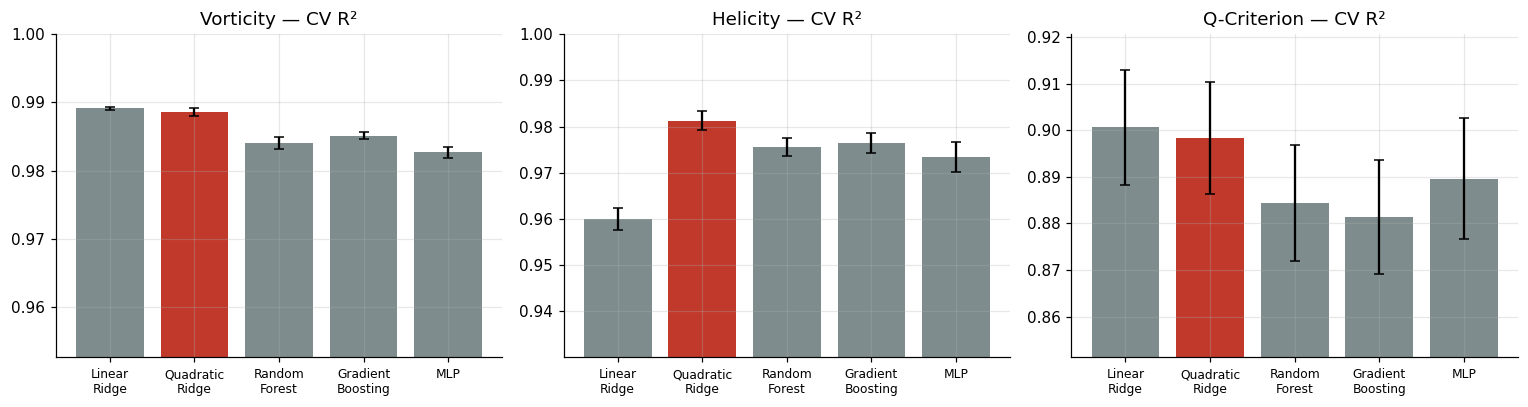

[18:15:05  +   177s] 💾 stage 'cv' saved to Drive cache


,target,model,R2_mean,R2_sd,RMSE_mean,RMSE_sd,MAE_mean,nRMSE_mean
0,Helicity,Gradient Boosting,0.9764,0.0022,30.7156,1.0371,24.6340,0.1534
1,Helicity,Linear Ridge,0.9600,0.0024,40.0206,0.4571,31.6956,0.1999
2,Helicity,MLP,0.9734,0.0033,32.5869,1.4741,26.0974,0.1628
3,Helicity,Quadratic Ridge,0.9813,0.0020,27.3387,1.0011,21.8285,0.1366
4,Helicity,Random Forest,0.9756,0.0020,31.2534,0.6710,25.0752,0.1561
5,Q-Criterion,Gradient Boosting,0.8813,0.0122,1398.1085,53.1501,1122.1614,0.3441
6,Q-Criterion,Linear Ridge,0.9006,0.0122,1279.2584,75.0339,1030.4623,0.3148
7,Q-Criterion,MLP,0.8896,0.0130,1348.4919,77.5190,1082.7915,0.3318
8,Q-Criterion,Quadratic Ridge,0.8983,0.0119,1293.9284,73.8771,1039.2893,0.3184
9,Q-Criterion,Random Forest,0.8843,0.0124,1380.6577,68.0168,1110.3983,0.3397


,model,mean_R2,mean_nRMSE,rank
0,Quadratic Ridge,0.9561,0.1872,1
1,Linear Ridge,0.9499,0.2063,2
2,Gradient Boosting,0.9476,0.2065,3
3,Random Forest,0.9480,0.2074,4
4,MLP,0.9486,0.2087,5


🏁 Best baseline by mean normalised CV-RMSE: Quadratic Ridge   |   Selected for the explanation audit: Quadratic Ridge


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 5 · 5-FOLD CV ON THE TRAINING PARTITION — five regression baselines
# ═══════════════════════════════════════════════════════════════════════════
if stage_done("cv"):
    CV = load_stage("cv")
    show_saved("fig_cv_baselines")
else:
    kf = KFold(CV_FOLDS, shuffle=True, random_state=SEED)
    fold_rows = []
    for lab in LABS:
        for mname in MODEL_NAMES:
            t0 = time.time()
            for f, (a, b) in enumerate(kf.split(Xtr)):
                m = make_model(mname).fit(Xtr[a], Y[lab][idx_tr][a])
                fold_rows.append(dict(target=lab, model=mname, fold=f, **reg_metrics(Y[lab][idx_tr][b], m.predict(Xtr[b]))))
            log(f"CV  {lab:12s} {mname:18s} done in {time.time()-t0:5.1f}s")
    folds = pd.DataFrame(fold_rows)
    summ = folds.groupby(["target", "model"]).agg(R2_mean=("R2", "mean"), R2_sd=("R2", "std"), RMSE_mean=("RMSE", "mean"),
                                                  RMSE_sd=("RMSE", "std"), MAE_mean=("MAE", "mean"), nRMSE_mean=("nRMSE", "mean")).reset_index()
    rank = summ.groupby("model").agg(mean_R2=("R2_mean", "mean"), mean_nRMSE=("nRMSE_mean", "mean")).sort_values("mean_nRMSE").reset_index()
    rank["rank"] = np.arange(1, len(rank) + 1)
    CV = dict(folds=folds, summary=summ, ranking=rank, winner=str(rank.model.iloc[0]))
    save_table(folds, "cv_folds"); save_table(summ, "cv_summary"); save_table(rank, "cv_model_ranking")
    fig, ax = plt.subplots(1, 3, figsize=(14, 3.8), sharey=False)
    for a_, lab in zip(ax, LABS):
        s = summ[summ.target == lab].set_index("model").loc[MODEL_NAMES]
        cols = ["#c0392b" if mname == SELECTED_MODEL else "#7f8c8d" for mname in MODEL_NAMES]
        a_.bar(range(len(s)), s.R2_mean, yerr=s.R2_sd, color=cols, capsize=3)
        a_.set_xticks(range(len(s))); a_.set_xticklabels([m.replace(" ", "\n") for m in s.index], fontsize=8)
        lo = max(0, s.R2_mean.min() - 0.03); a_.set_ylim(lo, min(1.0, s.R2_mean.max() + 0.02)); a_.set_title(f"{lab} — CV R²")
    savefig(fig, "fig_cv_baselines")
    save_stage("cv", CV)

display(CV["summary"].round(4)); display(CV["ranking"].round(4))
print(f"🏁 Best baseline by mean normalised CV-RMSE: {CV['winner']}   |   Selected for the explanation audit: {SELECTED_MODEL}")
if CV["winner"] != SELECTED_MODEL:
    r = CV["ranking"].set_index("model")
    print(f"ℹ️  {SELECTED_MODEL} is within {r.loc[SELECTED_MODEL,'mean_nRMSE']-r.loc[CV['winner'],'mean_nRMSE']:+.4f} nRMSE of the CV winner. "
          "It is retained because only a polynomial model allows exact SHAP and analytic derivatives — the point of the study.")


## 6 · Selected model — prediction evaluation

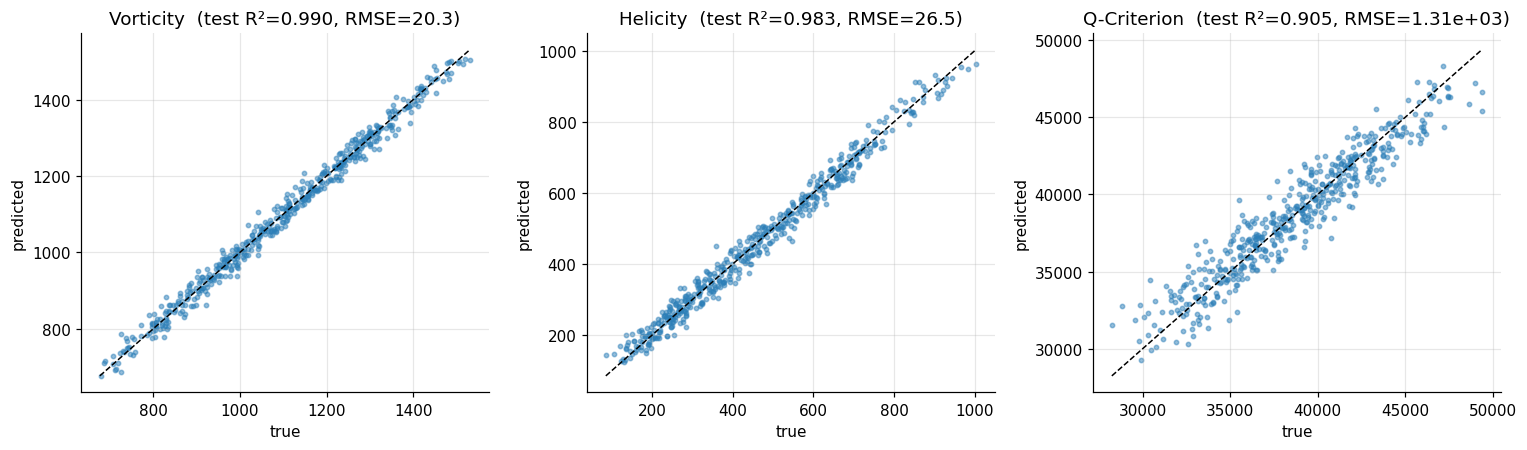

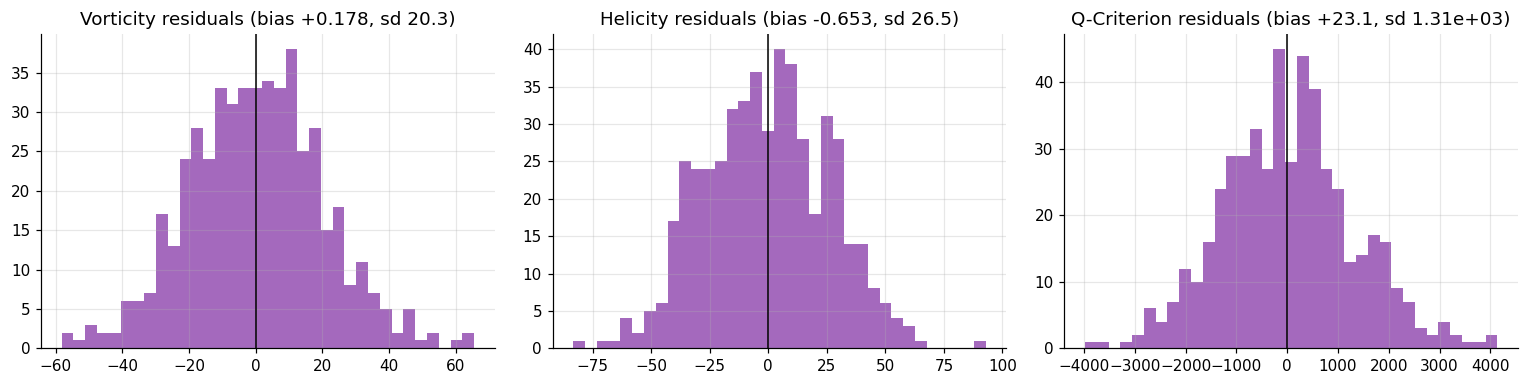

[18:15:50  +   222s] 💾 stage 'final' saved to Drive cache


,target,partition,R2,RMSE,MAE,nRMSE,Bias
0,Vorticity,train,0.9900,19.3987,15.3141,0.1000,-0.0000
1,Vorticity,calibration,0.9897,19.6993,15.6089,0.1015,-0.5008
2,Vorticity,test,0.9898,20.3183,16.2196,0.1012,0.1779
3,Helicity,train,0.9835,25.7556,20.5441,0.1285,0.0000
4,Helicity,calibration,0.9836,26.6994,21.2777,0.1279,-0.0334
5,Helicity,test,0.9832,26.5291,21.6305,0.1295,-0.6525
6,Q-Criterion,train,0.9088,1231.6811,985.6078,0.3020,-0.0000
7,Q-Criterion,calibration,0.9001,1309.9952,1043.1268,0.3161,-6.3759
8,Q-Criterion,test,0.9050,1310.4048,1030.1930,0.3083,23.1355


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 6 · FINAL MODEL (fit on the 1500 training rows) + PREDICTION EVALUATION
# ═══════════════════════════════════════════════════════════════════════════
if stage_done("final"):
    FINAL = load_stage("final")
    show_saved("fig_parity_test", "fig_residuals_test")
else:
    models = {lab: make_model(SELECTED_MODEL).fit(Xtr, Y[lab][idx_tr]) for lab in LABS}
    rows, preds = [], {}
    for lab in LABS:
        m = models[lab]
        for part, idx in [("train", idx_tr), ("calibration", idx_cal), ("test", idx_te)]:
            p = m.predict(X[idx]); rows.append(dict(target=lab, partition=part, **reg_metrics(Y[lab][idx], p)))
            if part == "test": preds[lab] = p
        joblib.dump(m, MODEL_DIR / f"{SELECTED_MODEL.replace(' ', '_').lower()}_{lab.lower().replace('-', '_')}.joblib")
    met = pd.DataFrame(rows)
    pred_tbl = pd.DataFrame({"row": idx_te, **{f"{lab}_true": Y[lab][idx_te] for lab in LABS}, **{f"{lab}_pred": preds[lab] for lab in LABS}})
    save_table(met, "final_model_metrics"); save_table(pred_tbl, "test_predictions")
    alphas = pd.DataFrame({"target": LABS, "ridge_alpha": [models[l].alpha_ for l in LABS]}); save_table(alphas, "final_model_ridge_alpha")
    fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))
    for a_, lab in zip(ax, LABS):
        y, p = Y[lab][idx_te], preds[lab]
        a_.scatter(y, p, s=8, alpha=0.5, color="#2c7fb8"); lo, hi = min(y.min(), p.min()), max(y.max(), p.max())
        a_.plot([lo, hi], [lo, hi], "k--", lw=1)
        r = met[(met.target == lab) & (met.partition == "test")].iloc[0]
        a_.set_title(f"{lab}  (test R²={r.R2:.3f}, RMSE={r.RMSE:.3g})"); a_.set_xlabel("true"); a_.set_ylabel("predicted")
    savefig(fig, "fig_parity_test")
    fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
    for a_, lab in zip(ax, LABS):
        res = preds[lab] - Y[lab][idx_te]
        a_.hist(res, bins=35, color="#8e44ad", alpha=0.8); a_.axvline(0, c="k", lw=1)
        a_.set_title(f"{lab} residuals (bias {res.mean():+.3g}, sd {res.std():.3g})")
    savefig(fig, "fig_residuals_test")
    FINAL = dict(models=models, metrics=met, preds=preds, alphas=alphas)
    save_stage("final", FINAL)

MODELS = FINAL["models"]
display(FINAL["metrics"].round(4))


## 7 · Uncertainty — split-conformal intervals

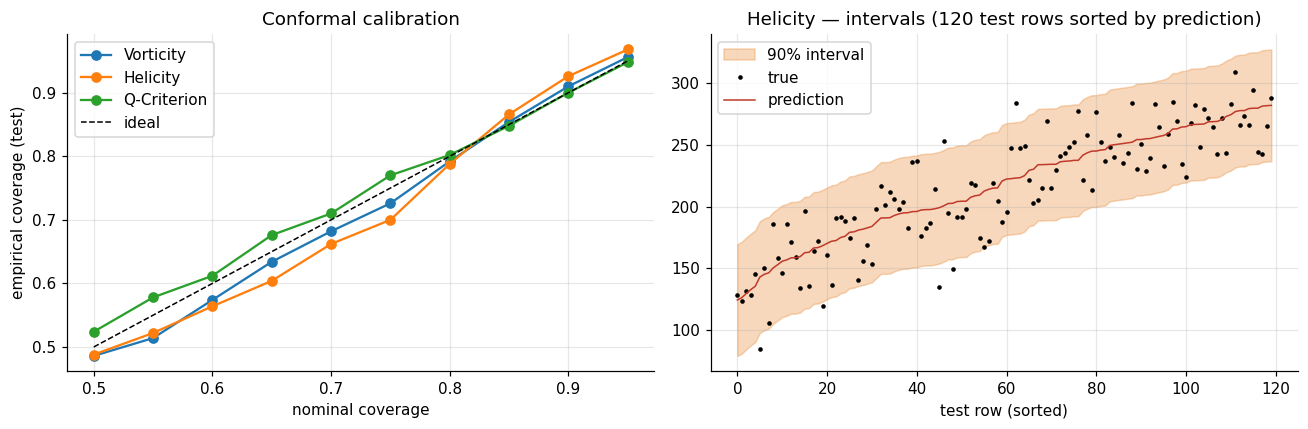

[18:16:02  +   234s] 💾 stage 'conformal' saved to Drive cache


,target,nominal,empirical_coverage,half_width,mean_width,width_over_target_sd
0,Vorticity,0.9,0.910,34.0966,68.1932,0.3397
1,Helicity,0.9,0.926,45.2153,90.4305,0.4413
2,Q-Criterion,0.9,0.900,2136.9748,4273.9495,1.0054


,target,swirl_tercile,n,coverage
0,Vorticity,low,167,0.910
1,Vorticity,mid,166,0.892
2,Vorticity,high,167,0.928
3,Helicity,low,167,0.934
4,Helicity,mid,166,0.916
5,Helicity,high,167,0.928
6,Q-Criterion,low,167,0.880
7,Q-Criterion,mid,166,0.934
8,Q-Criterion,high,167,0.886


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 7 · UNCERTAINTY — split-conformal prediction intervals (calibration partition)
# ═══════════════════════════════════════════════════════════════════════════
if stage_done("conformal"):
    CONF = load_stage("conformal")
    show_saved("fig_conformal_coverage", "fig_conformal_band")
else:
    rows, cond_rows, curves, ints = [], [], {}, {}
    swirl_te = Xte[:, SWIRL_J]; edges = np.quantile(swirl_te, [0, 1/3, 2/3, 1])
    for lab in LABS:
        m = MODELS[lab]; s = np.abs(Y[lab][idx_cal] - m.predict(Xcal)); p = m.predict(Xte); y = Y[lab][idx_te]
        q = conformal_q(s, ALPHA_CONF); lo, hi = p - q, p + q
        cov = float(np.mean((y >= lo) & (y <= hi)))
        rows.append(dict(target=lab, nominal=1 - ALPHA_CONF, empirical_coverage=cov, half_width=q, mean_width=2 * q, width_over_target_sd=2 * q / y.std()))
        ints[lab] = (lo, hi)
        grid = np.linspace(0.05, 0.5, 10)
        curves[lab] = [(1 - a, float(np.mean(np.abs(y - p) <= conformal_q(s, a)))) for a in grid]
        for k in range(3):
            msk = (swirl_te >= edges[k]) & (swirl_te <= edges[k + 1]) if k == 2 else (swirl_te >= edges[k]) & (swirl_te < edges[k + 1])
            cond_rows.append(dict(target=lab, swirl_tercile=["low", "mid", "high"][k], n=int(msk.sum()), coverage=float(np.mean((y[msk] >= lo[msk]) & (y[msk] <= hi[msk])))))
    cov_tbl, cond_tbl = pd.DataFrame(rows), pd.DataFrame(cond_rows)
    save_table(cov_tbl, "conformal_coverage"); save_table(cond_tbl, "conformal_coverage_by_swirl_tercile")
    save_table(pd.DataFrame({"row": idx_te, **{f"{l}_{k}": v for l in LABS for k, v in zip(["lower", "upper"], ints[l])}}), "conformal_test_intervals")
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    for lab in LABS:
        c = np.array(curves[lab]); ax[0].plot(c[:, 0], c[:, 1], "o-", label=lab)
    ax[0].plot([0.5, 0.95], [0.5, 0.95], "k--", lw=1, label="ideal"); ax[0].set_xlabel("nominal coverage"); ax[0].set_ylabel("empirical coverage (test)"); ax[0].legend(); ax[0].set_title("Conformal calibration")
    lab = "Helicity"; p = MODELS[lab].predict(Xte); o = np.argsort(p)[:120]; lo, hi = ints[lab]
    ax[1].fill_between(range(len(o)), lo[o], hi[o], alpha=0.3, color="#e67e22", label=f"{int((1-ALPHA_CONF)*100)}% interval")
    ax[1].plot(Y[lab][idx_te][o], "k.", ms=4, label="true"); ax[1].plot(p[o], "-", c="#c0392b", lw=1, label="prediction")
    ax[1].set_title("Helicity — intervals (120 test rows sorted by prediction)"); ax[1].legend(); ax[1].set_xlabel("test row (sorted)")
    savefig(fig, "fig_conformal_coverage")
    CONF = dict(coverage=cov_tbl, cond=cond_tbl, intervals=ints)
    save_stage("conformal", CONF)

display(CONF["coverage"].round(4)); display(CONF["cond"].round(3))


## 8 · Explanation audit ① — exact SHAP
For a quadratic model, Shapley values have a closed form; the cell verifies it against the brute-force definition (all 2¹² coalitions) on a test row.

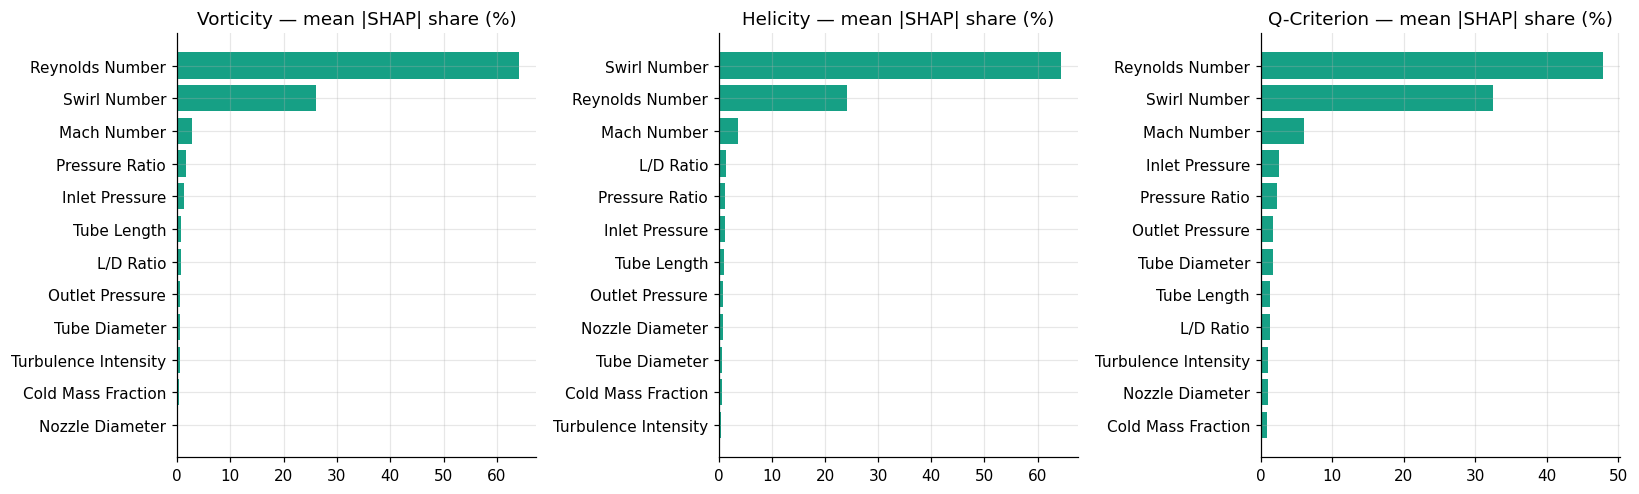

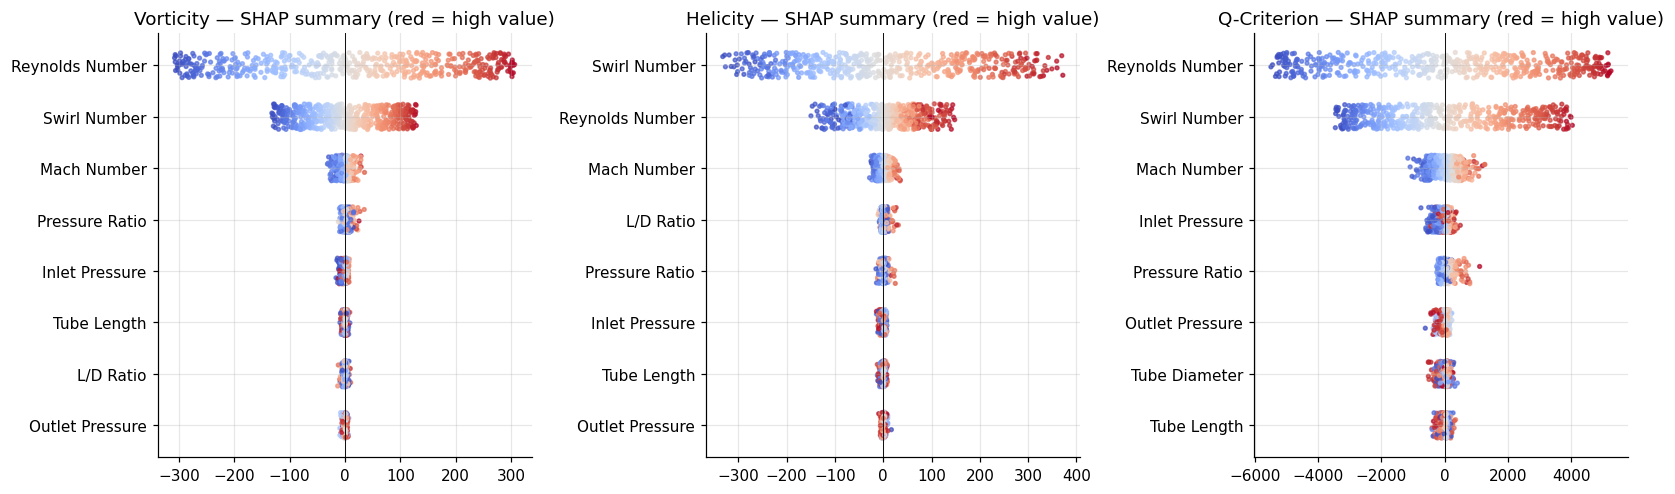

[18:16:15  +   247s] 💾 stage 'shap' saved to Drive cache


,target,additivity_max_abs_err,brute_force_max_abs_diff
0,Vorticity,4.547474e-13,1.421085e-13
1,Helicity,3.410605e-13,8.526513e-14
2,Q-Criterion,7.275958e-12,9.094947e-13


✅ Closed-form SHAP matches the definition-level (2^12 coalition) Shapley values and is additive.


target,Helicity,Q-Criterion,Vorticity,mean
feature,,,,
Reynolds Number,24.16,47.86,64.17,45.40
Swirl Number,64.45,32.47,26.14,41.02
Mach Number,3.58,6.02,2.83,4.14
Pressure Ratio,1.17,2.22,1.66,1.69
Inlet Pressure,1.15,2.51,1.39,1.68
L/D Ratio,1.35,1.29,0.70,1.11
Outlet Pressure,0.81,1.72,0.63,1.05
Tube Length,0.95,1.32,0.73,1.00
Tube Diameter,0.65,1.71,0.53,0.96


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 8 · EXPLANATION AUDIT (1/3) — EXACT SHAP  (closed form + brute-force verification)
# ═══════════════════════════════════════════════════════════════════════════
if stage_done("shap"):
    SHAP = load_stage("shap")
    show_saved("fig_shap_importance", "fig_shap_summary")
else:
    rows, res, verify = [], {}, []
    for lab in LABS:
        m = MODELS[lab]
        phi_te, base = quad_shap(m, Xte, Xtr)
        phi_cal, _ = quad_shap(m, Xcal, Xtr)
        add_err = float(np.max(np.abs(base + phi_te.sum(1) - m.predict(Xte))))
        # brute-force verification of the closed form on 1 test row (40 background rows, all 2^12 coalitions)
        bg = Xtr[:40]; x0 = Xte[0]
        phi_bf, v0 = brute_shapley(m.predict, x0, bg)
        phi_cf, _ = quad_shap(m, x0[None, :], bg)
        verify.append(dict(target=lab, additivity_max_abs_err=add_err, brute_force_max_abs_diff=float(np.max(np.abs(phi_bf - phi_cf[0])))))
        res[lab] = dict(phi_te=phi_te, phi_cal=phi_cal, base=base, mean_abs=np.abs(phi_te).mean(0))
        for j, f in enumerate(FEATS):
            rows.append(dict(target=lab, feature=f, mean_abs_shap=res[lab]["mean_abs"][j], share_pct=100 * res[lab]["mean_abs"][j] / res[lab]["mean_abs"].sum()))
    shap_tbl = pd.DataFrame(rows); ver = pd.DataFrame(verify)
    save_table(shap_tbl, "shap_global_importance"); save_table(ver, "shap_verification")
    for lab in LABS: pd.DataFrame(res[lab]["phi_te"], columns=FEATS).assign(row=idx_te).to_csv(TAB_DIR / f"shap_values_test_{lab.lower().replace('-', '_')}.csv", index=False)
    fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
    for a_, lab in zip(ax, LABS):
        s = shap_tbl[shap_tbl.target == lab].sort_values("share_pct")
        a_.barh(s.feature, s.share_pct, color="#16a085"); a_.set_title(f"{lab} — mean |SHAP| share (%)")
    savefig(fig, "fig_shap_importance")
    rs = np.random.default_rng(SEED)
    fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
    for a_, lab in zip(ax, LABS):
        phi = res[lab]["phi_te"]; order = np.argsort(-np.abs(phi).mean(0))[:8][::-1]
        for r, j in enumerate(order):
            v = Xte[:, j]; c = (v - v.min()) / (np.ptp(v) + 1e-12)
            a_.scatter(phi[:, j], r + rs.uniform(-0.25, 0.25, len(v)), c=c, cmap="coolwarm", s=6, alpha=0.7)
        a_.set_yticks(range(len(order))); a_.set_yticklabels([FEATS[j] for j in order]); a_.axvline(0, c="k", lw=0.6)
        a_.set_title(f"{lab} — SHAP summary (red = high value)")
    savefig(fig, "fig_shap_summary")
    SHAP = dict(table=shap_tbl, res=res, verify=ver)
    save_stage("shap", SHAP)

display(SHAP["verify"])
ok = (SHAP["verify"].additivity_max_abs_err.max() < 1e-6 * max(np.std(Y[l]) for l in LABS)) and (SHAP["verify"].brute_force_max_abs_diff.max() < 1e-6 * max(np.std(Y[l]) for l in LABS))
print("✅ Closed-form SHAP matches the definition-level (2^12 coalition) Shapley values and is additive." if ok else "⚠️ SHAP verification tolerance exceeded — inspect table above.")
piv = SHAP["table"].pivot(index="feature", columns="target", values="share_pct").loc[FEATS]
display(piv.assign(mean=piv.mean(1)).sort_values("mean", ascending=False).round(2))


## 9 · Explanation audit ② — permutation importance vs SHAP

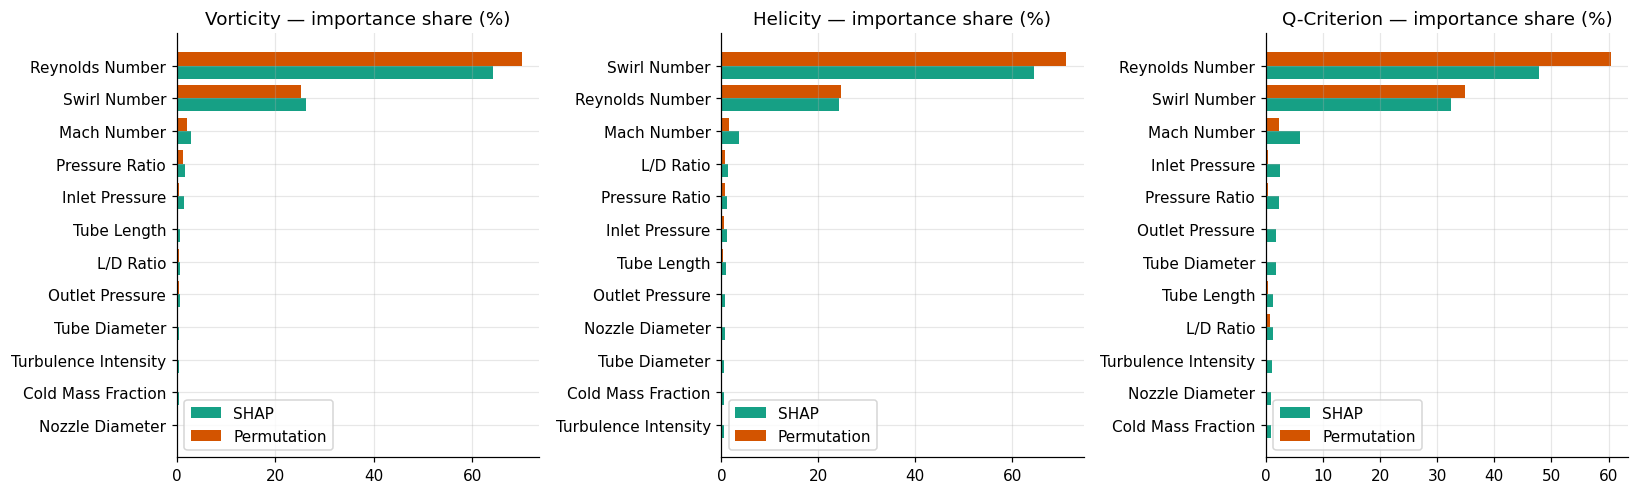

[18:16:35  +   267s] 💾 stage 'perm' saved to Drive cache


,target,spearman_shap_vs_perm,top3_overlap,top3_shap,top3_perm
0,Vorticity,0.951049,3,"[Reynolds Number, Swirl Number, Mach Number]","[Reynolds Number, Swirl Number, Mach Number]"
1,Helicity,0.965035,3,"[Swirl Number, Reynolds Number, Mach Number]","[Swirl Number, Reynolds Number, Mach Number]"
2,Q-Criterion,0.846154,3,"[Reynolds Number, Swirl Number, Mach Number]","[Reynolds Number, Swirl Number, Mach Number]"


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 9 · EXPLANATION AUDIT (2/3) — PERMUTATION IMPORTANCE vs SHAP
# ═══════════════════════════════════════════════════════════════════════════
if stage_done("perm"):
    PERM = load_stage("perm")
    show_saved("fig_shap_vs_perm")
else:
    rp = np.random.default_rng(SEED + 1); rows, agree = [], []
    for lab in LABS:
        m, y = MODELS[lab], Y[lab][idx_te]; base_rmse = np.sqrt(np.mean((m.predict(Xte) - y) ** 2))
        imp = np.zeros((X.shape[1], PERM_REPEATS))
        for j in range(X.shape[1]):
            for r in range(PERM_REPEATS):
                Xp = Xte.copy(); Xp[:, j] = rp.permutation(Xp[:, j]); imp[j, r] = np.sqrt(np.mean((m.predict(Xp) - y) ** 2)) - base_rmse
        mean_imp = np.clip(imp.mean(1), 0, None)
        for j, f in enumerate(FEATS):
            rows.append(dict(target=lab, feature=f, rmse_increase=imp[j].mean(), rmse_increase_sd=imp[j].std(), share_pct=100 * mean_imp[j] / (mean_imp.sum() + 1e-12)))
        sh = SHAP["res"][lab]["mean_abs"]
        top3_s, top3_p = set(np.argsort(-sh)[:3]), set(np.argsort(-mean_imp)[:3])
        rho = stats.spearmanr(sh, mean_imp).correlation
        agree.append(dict(target=lab, spearman_shap_vs_perm=rho, top3_overlap=len(top3_s & top3_p),
                          top3_shap=[FEATS[j] for j in np.argsort(-sh)[:3]], top3_perm=[FEATS[j] for j in np.argsort(-mean_imp)[:3]]))
    perm_tbl, agree_tbl = pd.DataFrame(rows), pd.DataFrame(agree)
    save_table(perm_tbl, "permutation_importance"); save_table(agree_tbl, "shap_vs_permutation_agreement")
    fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
    for a_, lab in zip(ax, LABS):
        s = SHAP["table"][SHAP["table"].target == lab].set_index("feature").loc[FEATS]; p_ = perm_tbl[perm_tbl.target == lab].set_index("feature").loc[FEATS]
        order = np.argsort(s.share_pct.values); yy = np.arange(len(order))
        a_.barh(yy - 0.2, s.share_pct.values[order], height=0.4, label="SHAP", color="#16a085")
        a_.barh(yy + 0.2, p_.share_pct.values[order], height=0.4, label="Permutation", color="#d35400")
        a_.set_yticks(yy); a_.set_yticklabels(np.array(FEATS)[order]); a_.set_title(f"{lab} — importance share (%)"); a_.legend()
    savefig(fig, "fig_shap_vs_perm")
    PERM = dict(table=perm_tbl, agree=agree_tbl)
    save_stage("perm", PERM)

display(PERM["agree"])


## 10 · Explanation audit ③ — derivative fidelity

[18:16:45  +   278s] derivative fidelity Vorticity: 0.3s
[18:16:46  +   278s] derivative fidelity Helicity: 0.2s
[18:16:46  +   278s] derivative fidelity Q-Criterion: 0.2s


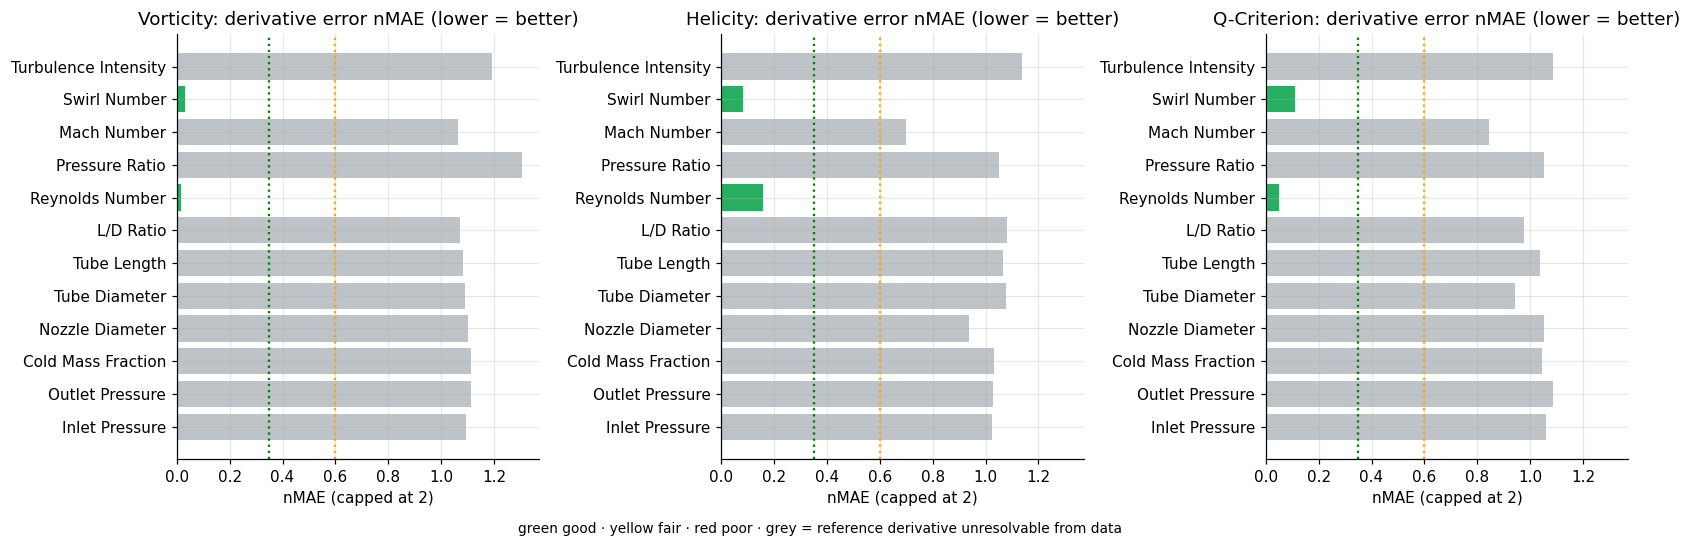

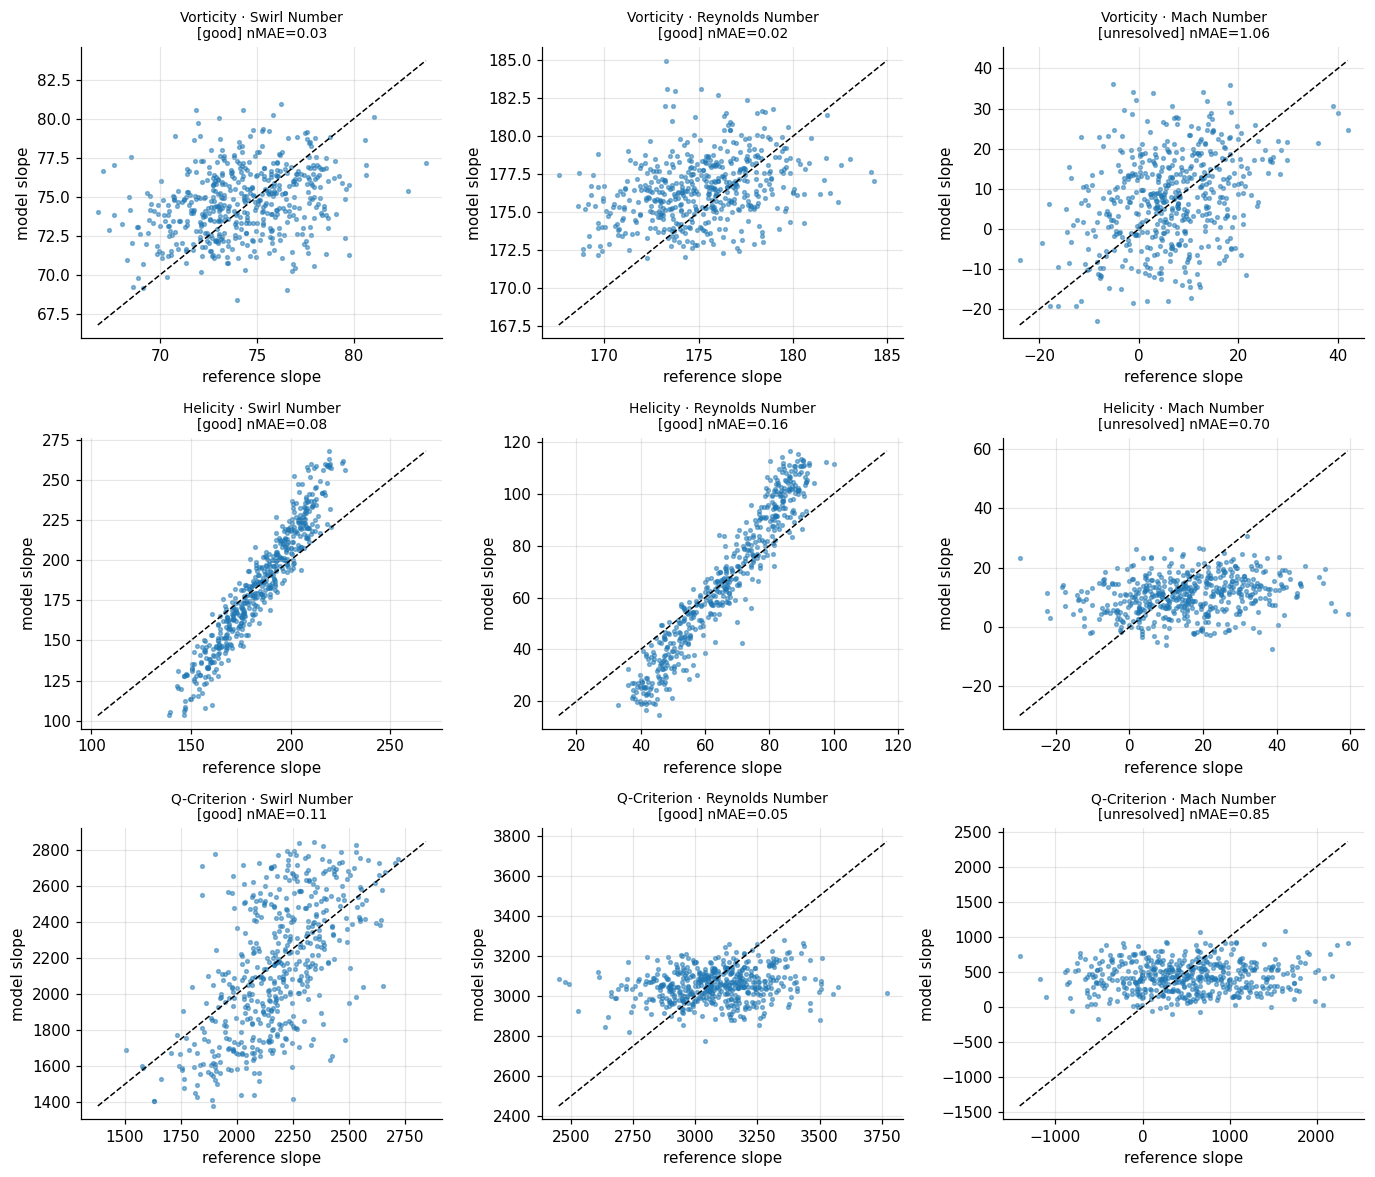

[18:16:49  +   281s] 💾 stage 'deriv' saved to Drive cache

Vorticity: fidelity score over resolvable features = 0.976   (resolvable 2/12 features)

Helicity: fidelity score over resolvable features = 0.880   (resolvable 2/12 features)

Q-Criterion: fidelity score over resolvable features = 0.921   (resolvable 2/12 features)


,target,feature,ref_mean_abs,ref_snr,resolvable,corr,sign_agree,nMAE,slope_ratio,grade
0,Vorticity,Inlet Pressure,7.404,0.337,False,0.309,0.646,1.092,1.226,unresolved
1,Vorticity,Outlet Pressure,4.561,0.324,False,0.199,0.578,1.112,-0.218,unresolved
2,Vorticity,Cold Mass Fraction,2.207,0.350,False,0.330,0.588,1.115,0.841,unresolved
3,Vorticity,Nozzle Diameter,2.093,0.307,False,0.273,0.582,1.103,1.018,unresolved
4,Vorticity,Tube Diameter,4.529,0.351,False,0.169,0.572,1.091,1.130,unresolved
5,Vorticity,Tube Length,6.911,0.335,False,0.128,0.518,1.081,0.001,unresolved
6,Vorticity,L/D Ratio,8.055,0.318,False,0.102,0.524,1.070,-0.199,unresolved
7,Vorticity,Reynolds Number,175.118,31.872,True,0.317,1.000,0.015,1.008,good
8,Vorticity,Pressure Ratio,8.476,0.331,False,0.237,0.610,1.305,0.422,unresolved
9,Vorticity,Mach Number,9.352,0.378,False,0.325,0.690,1.064,1.224,unresolved


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 10 · EXPLANATION AUDIT (3/3) — DERIVATIVE FIDELITY
#   Does the model's local sensitivity dY/dx_j match a data-driven local-linear reference?
#   Reference = tricube-weighted local ridge regression on train+calibration rows, evaluated at the test rows.
#   Features whose reference slope cannot be resolved from the data (|slope|/SE < FID_SNR_MIN) are reported as
#   'unresolved' rather than 'poor' — the data cannot judge them.
# ═══════════════════════════════════════════════════════════════════════════
if stage_done("deriv"):
    DERIV = load_stage("deriv")
    show_saved("fig_derivative_fidelity", "fig_gradient_scatter")
else:
    idx_ref = np.r_[idx_tr, idx_cal]; Zref = (X[idx_ref] - x_mean) / x_std; Zq = (Xte - x_mean) / x_std
    G_model, G_ref, SE_ref, tbls = {}, {}, {}, []
    for lab in LABS:
        t0 = time.time()
        G_model[lab] = fd_grad(MODELS[lab].predict, Xte, x_std)
        G_ref[lab], SE_ref[lab] = local_linear_grad(Zref, Y[lab][idx_ref], Zq)
        t = fidelity_table(G_model[lab], G_ref[lab], SE_ref[lab], FEATS); t.insert(0, "target", lab); tbls.append(t)
        log(f"derivative fidelity {lab}: {time.time()-t0:.1f}s")
    fid = pd.concat(tbls, ignore_index=True); save_table(fid, "derivative_fidelity")
    # joined audit table: what each method says about each feature
    aud = fid.merge(SHAP["table"][["target", "feature", "share_pct"]].rename(columns={"share_pct": "shap_share_pct"}), on=["target", "feature"]) \
             .merge(PERM["table"][["target", "feature", "share_pct"]].rename(columns={"share_pct": "perm_share_pct"}), on=["target", "feature"])
    save_table(aud, "explanation_audit_joined")
    fig, ax = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True)
    for a_, lab in zip(ax, LABS):
        t = fid[fid.target == lab].set_index("feature").loc[FEATS]
        colr = t.grade.map({"good": "#27ae60", "fair": "#f1c40f", "poor": "#c0392b", "unresolved": "#bdc3c7"})
        a_.barh(range(len(t)), np.minimum(t.nMAE.values, 2.0), color=colr); a_.set_yticks(range(len(t))); a_.set_yticklabels(t.index)
        a_.axvline(FID_NMAE_GOOD, c="g", ls=":"); a_.axvline(FID_NMAE_FAIR, c="orange", ls=":")
        a_.set_title(f"{lab}: derivative error nMAE (lower = better)"); a_.set_xlabel("nMAE (capped at 2)")
    fig.text(0.5, -0.02, "green good · yellow fair · red poor · grey = reference derivative unresolvable from data", ha="center", fontsize=9)
    savefig(fig, "fig_derivative_fidelity")
    show_feats = [f for f in ["Swirl Number", "Reynolds Number", "Mach Number"] if f in FEATS]
    fig, ax = plt.subplots(len(LABS), len(show_feats), figsize=(4.2 * len(show_feats), 3.6 * len(LABS)), squeeze=False)
    for i, lab in enumerate(LABS):
        for k, f in enumerate(show_feats):
            j = FEATS.index(f); a_ = ax[i, k]; a_.scatter(G_ref[lab][:, j], G_model[lab][:, j], s=6, alpha=0.5)
            lo, hi = min(G_ref[lab][:, j].min(), G_model[lab][:, j].min()), max(G_ref[lab][:, j].max(), G_model[lab][:, j].max()); a_.plot([lo, hi], [lo, hi], "k--", lw=1)
            g_ = fid[(fid.target == lab) & (fid.feature == f)].iloc[0]; a_.set_title(f"{lab} · {f}\n[{g_.grade}] nMAE={g_.nMAE:.2f}", fontsize=9)
            a_.set_xlabel("reference slope"); a_.set_ylabel("model slope")
    savefig(fig, "fig_gradient_scatter")
    DERIV = dict(fid=fid, joined=aud, G_model=G_model, G_ref=G_ref, SE_ref=SE_ref)
    save_stage("deriv", DERIV)

fid = DERIV["fid"]
for lab in LABS:
    print(f"\n{lab}: fidelity score over resolvable features = {fidelity_score(fid[fid.target == lab]):.3f}   "
          f"(resolvable {int(fid[fid.target == lab].resolvable.sum())}/{len(FEATS)} features)")
display(fid.round(3))


## 11 · Mach sensitivity — diagnosis of the weak spot
Why can the model’s Mach slope not be verified? (collinearity with pressure ratio / inlet pressure)

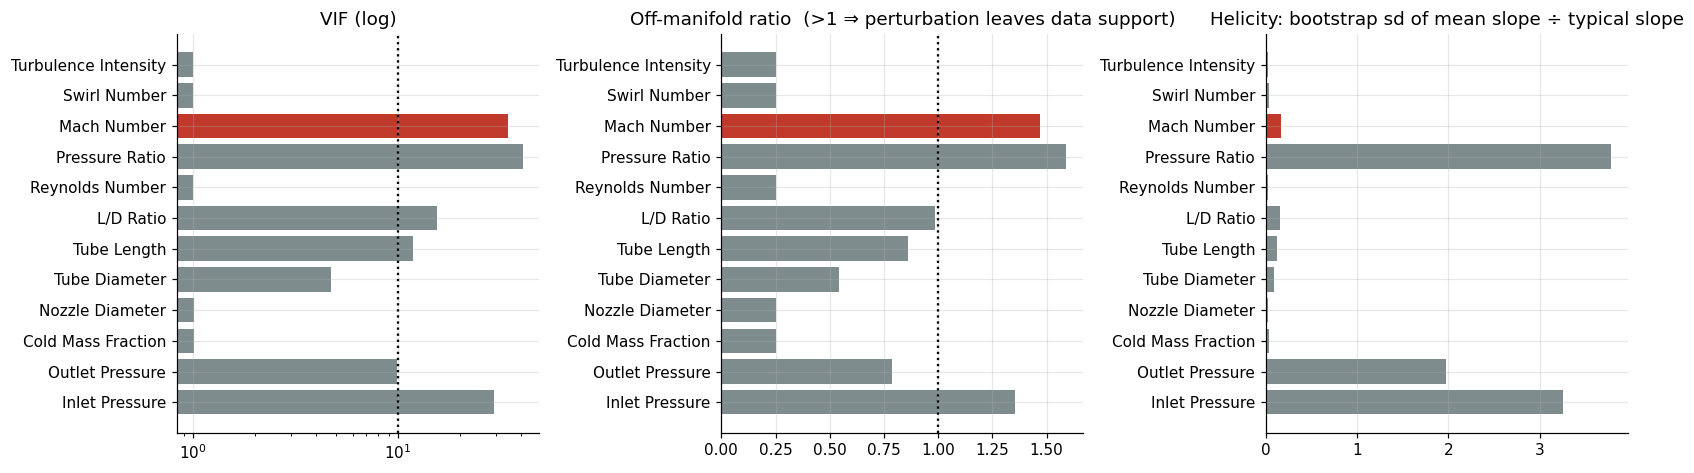

[18:17:23  +   315s] 💾 stage 'mach' saved to Drive cache


,VIF,off_manifold_ratio,boot_mean_slope,boot_sd,boot_sd_over_scale,sign_consistency
feature,,,,,,
Inlet Pressure,29.366,1.355,-14.054,83.607,3.261,0.600
Outlet Pressure,9.913,0.787,6.822,50.596,1.974,0.800
Cold Mass Fraction,1.006,0.251,-0.251,0.761,0.030,0.650
Nozzle Diameter,1.006,0.251,-1.439,0.723,0.028,0.975
Tube Diameter,4.720,0.543,-1.493,2.225,0.087,0.825
Tube Length,11.817,0.859,2.365,3.160,0.123,0.850
L/D Ratio,15.580,0.987,-2.659,3.878,0.151,0.975
Reynolds Number,1.004,0.251,66.437,0.683,0.027,1.000
Pressure Ratio,40.500,1.591,14.849,96.885,3.779,0.500


Mach-number derivative fidelity per target:


,target,ref_snr,resolvable,sign_agree,nMAE,grade
9,Vorticity,0.378,False,0.690,1.064,unresolved
21,Helicity,0.498,False,0.806,0.700,unresolved
33,Q-Criterion,0.442,False,0.750,0.845,unresolved


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 11 · WHY IS MACH SENSITIVITY POOR?  identifiability diagnostics for every input
#   • VIF / R² of each input regressed on the others
#   • off-manifold ratio: finite-difference step ÷ residual spread of that input given the others
#     (>1 ⇒ the "hold everything else fixed" perturbation leaves the region the data actually covers)
#   • bootstrap stability of the model's mean slope (40 refits)
# ═══════════════════════════════════════════════════════════════════════════
if stage_done("mach"):
    MACH = load_stage("mach")
    show_saved("fig_mach_identifiability")
else:
    vif = AUDIT["vif"].set_index("feature").loc[FEATS]
    resid_ratio = FD_STEP / np.sqrt(np.clip(1 - vif.R2_vs_others.values, 1e-9, 1))
    rb = np.random.default_rng(SEED + 2); sub = rb.choice(len(Xte), size=min(200, len(Xte)), replace=False)
    boot = {lab: np.zeros((N_BOOT, X.shape[1])) for lab in LABS}
    for b in range(N_BOOT):
        ib = rb.choice(len(Xtr), size=len(Xtr), replace=True)
        for lab in LABS:
            mb = make_model(SELECTED_MODEL).fit(Xtr[ib], Y[lab][idx_tr][ib])
            boot[lab][b] = fd_grad(mb.predict, Xte[sub], x_std).mean(0)
    rows = []
    for lab in LABS:
        gm = boot[lab]; scale = np.mean(np.abs(gm.mean(0)))
        for j, f in enumerate(FEATS):
            sg = np.sign(gm[:, j]); rows.append(dict(target=lab, feature=f, VIF=vif.VIF.values[j], R2_vs_others=vif.R2_vs_others.values[j], off_manifold_ratio=resid_ratio[j],
                     boot_mean_slope=gm[:, j].mean(), boot_sd=gm[:, j].std(), boot_sd_over_scale=gm[:, j].std() / (scale + 1e-12),
                     sign_consistency=max(np.mean(sg > 0), np.mean(sg < 0))))
    ident = pd.DataFrame(rows); save_table(ident, "mach_identifiability_diagnostics")
    fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
    v = vif.VIF.values; colr = ["#c0392b" if f == "Mach Number" else "#7f8c8d" for f in FEATS]
    ax[0].barh(FEATS, v, color=colr); ax[0].set_xscale("log"); ax[0].set_title("VIF (log)"); ax[0].axvline(10, c="k", ls=":")
    ax[1].barh(FEATS, resid_ratio, color=colr); ax[1].axvline(1, c="k", ls=":"); ax[1].set_title("Off-manifold ratio  (>1 ⇒ perturbation leaves data support)")
    hb = ident[ident.target == "Helicity"].set_index("feature").loc[FEATS] if "Helicity" in LABS else ident.iloc[:len(FEATS)]
    ax[2].barh(FEATS, hb.boot_sd_over_scale.values, color=colr); ax[2].set_title("Helicity: bootstrap sd of mean slope ÷ typical slope")
    savefig(fig, "fig_mach_identifiability")
    MACH = dict(table=ident)
    save_stage("mach", MACH)

ident = MACH["table"]
h = ident[ident.target == LABS[1]].set_index("feature").loc[FEATS]
display(h[["VIF", "off_manifold_ratio", "boot_mean_slope", "boot_sd", "boot_sd_over_scale", "sign_consistency"]].round(3))
if MACH_COL:
    fm = DERIV["fid"][DERIV["fid"].feature == short(MACH_COL)][["target", "ref_snr", "resolvable", "sign_agree", "nMAE", "grade"]]
    print("Mach-number derivative fidelity per target:"); display(fm.round(3))


## 12 · 3-input ablation → improved derivative fidelity?

[18:17:30  +   322s] Ablation keeps 3 inputs: ['Reynolds Number', 'Swirl Number', 'Mach Number']


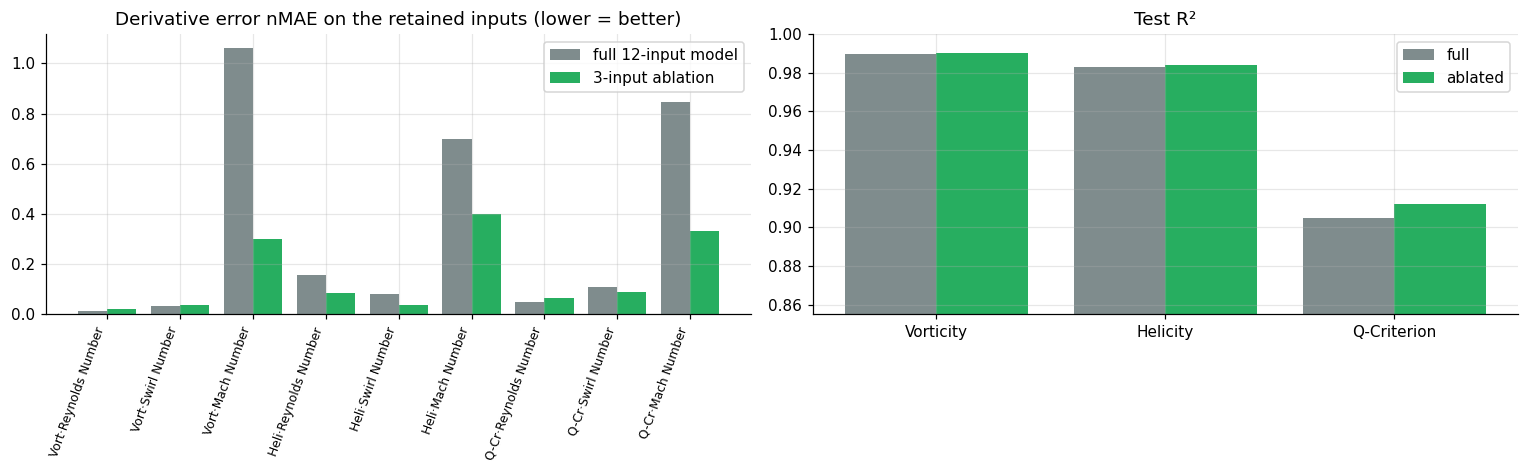

[18:17:32  +   324s] 💾 stage 'ablation' saved to Drive cache
Inputs kept: ['Reynolds Number', 'Swirl Number', 'Mach Number']


,target,R2_full,R2_ablated,dR2,RMSE_full,RMSE_ablated,conf_coverage_ablated,conf_width_ablated,conf_width_full
0,Vorticity,0.9898,0.9904,0.0006,20.3183,19.7158,0.902,64.3544,68.1932
1,Helicity,0.9832,0.9839,0.0006,26.5291,26.0163,0.920,87.9641,90.4305
2,Q-Criterion,0.9050,0.9121,0.0071,1310.4048,1260.2454,0.902,4259.9753,4273.9495


,target,feature,full_grade,full_nMAE,full_sign,full_ref_snr,abl_grade,abl_nMAE,abl_sign,abl_ref_snr,abl_vs12D_grade,abl_vs12D_nMAE
0,Vorticity,Reynolds Number,good,0.015,1.000,31.872,good,0.021,1.000,31.468,good,0.016
1,Vorticity,Swirl Number,good,0.032,1.000,13.723,good,0.040,1.000,13.557,good,0.034
2,Vorticity,Mach Number,unresolved,1.064,0.690,0.378,unresolved,0.300,1.000,1.865,unresolved,0.926
3,Helicity,Reynolds Number,good,0.158,1.000,7.376,good,0.087,1.000,7.773,good,0.161
4,Helicity,Swirl Number,good,0.082,1.000,21.339,good,0.037,1.000,24.676,good,0.085
5,Helicity,Mach Number,unresolved,0.700,0.806,0.498,unresolved,0.399,0.974,1.362,unresolved,0.710
6,Q-Criterion,Reynolds Number,good,0.048,1.000,8.734,good,0.067,1.000,8.742,good,0.050
7,Q-Criterion,Swirl Number,good,0.110,1.000,6.229,good,0.091,1.000,6.310,good,0.106
8,Q-Criterion,Mach Number,unresolved,0.845,0.750,0.442,unresolved,0.333,0.968,1.815,unresolved,0.845



Mean derivative error on the retained inputs — full model: 0.339  →  ablated model: 0.153   (IMPROVED)
Judged against the STRICTER 12-input (ceteris-paribus) reference instead: 0.339 → 0.326
Mean test-R² change from ablation: +0.0028


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 12 · 3-INPUT ABLATION — does removing redundant / collinear inputs restore derivative fidelity?
#   Inputs kept = top-N by mean normalised |SHAP| on the CALIBRATION partition (no test-set peeking),
#   unless ABLATION_FEATURES overrides.  Refit → re-evaluate accuracy, coverage and derivative fidelity.
# ═══════════════════════════════════════════════════════════════════════════
if stage_done("ablation"):
    ABL = load_stage("ablation")
    show_saved("fig_ablation")
else:
    if ABLATION_FEATURES:
        abl_idx = [INPUT_COLS.index(find(f)) for f in ABLATION_FEATURES]
    else:
        sc = np.mean([np.abs(SHAP["res"][l]["phi_cal"]).mean(0) / np.abs(SHAP["res"][l]["phi_cal"]).mean(0).sum() for l in LABS], axis=0)
        abl_idx = list(np.argsort(-sc)[:N_ABLATION])
    abl_feats = [FEATS[j] for j in abl_idx]
    log(f"Ablation keeps {len(abl_idx)} inputs: {abl_feats}")
    idx_ref = np.r_[idx_tr, idx_cal]
    xm_a, xs_a = x_mean[abl_idx], x_std[abl_idx]
    Zref_a = (X[idx_ref][:, abl_idx] - xm_a) / xs_a; Zq_a = (Xte[:, abl_idx] - xm_a) / xs_a
    comp, acc, models_a = [], [], {}
    for lab in LABS:
        m = make_model(SELECTED_MODEL).fit(Xtr[:, abl_idx], Y[lab][idx_tr]); models_a[lab] = m
        p_te, p_cal = m.predict(Xte[:, abl_idx]), m.predict(Xcal[:, abl_idx]); y = Y[lab][idx_te]
        q = conformal_q(np.abs(Y[lab][idx_cal] - p_cal), ALPHA_CONF); cov = float(np.mean(np.abs(y - p_te) <= q))
        full_m = FINAL["metrics"].query("target == @lab and partition == 'test'").iloc[0]; ab_m = reg_metrics(y, p_te)
        acc.append(dict(target=lab, R2_full=full_m.R2, R2_ablated=ab_m["R2"], dR2=ab_m["R2"] - full_m.R2, RMSE_full=full_m.RMSE, RMSE_ablated=ab_m["RMSE"],
                        conf_coverage_ablated=cov, conf_width_ablated=2 * q,
                        conf_width_full=float(CONF["coverage"].query("target == @lab").mean_width.iloc[0])))
        G_a = fd_grad(m.predict, Xte[:, abl_idx], xs_a); Gr_a, SEr_a = local_linear_grad(Zref_a, Y[lab][idx_ref], Zq_a)
        fa = fidelity_table(G_a, Gr_a, SEr_a, abl_feats)
        fa12 = fidelity_table(G_a, DERIV["G_ref"][lab][:, abl_idx], DERIV["SE_ref"][lab][:, abl_idx], abl_feats)   # stricter: vs the 12-input ceteris-paribus reference
        ff = DERIV["fid"].query("target == @lab").set_index("feature").loc[abl_feats].reset_index()
        for k, f in enumerate(abl_feats):
            comp.append(dict(target=lab, feature=f,
                             full_grade=ff.grade[k], full_nMAE=ff.nMAE[k], full_sign=ff.sign_agree[k], full_ref_snr=ff.ref_snr[k],
                             abl_grade=fa.grade[k], abl_nMAE=fa.nMAE[k], abl_sign=fa.sign_agree[k], abl_ref_snr=fa.ref_snr[k],
                             abl_vs12D_grade=fa12.grade[k], abl_vs12D_nMAE=fa12.nMAE[k]))
    comp, acc = pd.DataFrame(comp), pd.DataFrame(acc)
    save_table(comp, "ablation_derivative_fidelity"); save_table(acc, "ablation_accuracy")
    fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
    lbl = [f"{r.target[:4]}·{r.feature}" for r in comp.itertuples()]; xx = np.arange(len(comp))
    ax[0].bar(xx - 0.2, np.minimum(comp.full_nMAE, 2), 0.4, label="full 12-input model", color="#7f8c8d")
    ax[0].bar(xx + 0.2, np.minimum(comp.abl_nMAE, 2), 0.4, label=f"{len(abl_idx)}-input ablation", color="#27ae60")
    ax[0].set_xticks(xx); ax[0].set_xticklabels(lbl, rotation=70, ha="right", fontsize=8); ax[0].set_title("Derivative error nMAE on the retained inputs (lower = better)"); ax[0].legend()
    xa = np.arange(len(acc)); ax[1].bar(xa - 0.2, acc.R2_full, 0.4, label="full", color="#7f8c8d"); ax[1].bar(xa + 0.2, acc.R2_ablated, 0.4, label="ablated", color="#27ae60")
    ax[1].set_xticks(xa); ax[1].set_xticklabels(acc.target); ax[1].set_ylim(max(0, min(acc.R2_full.min(), acc.R2_ablated.min()) - 0.05), 1.0); ax[1].set_title("Test R²"); ax[1].legend()
    savefig(fig, "fig_ablation")
    ABL = dict(features=abl_feats, idx=abl_idx, comp=comp, acc=acc, models=models_a)
    save_stage("ablation", ABL)

print("Inputs kept:", ABL["features"]); display(ABL["acc"].round(4)); display(ABL["comp"].round(3))
_c = ABL["comp"]
print(f"\nMean derivative error on the retained inputs — full model: {_c.full_nMAE.mean():.3f}  →  ablated model: {_c.abl_nMAE.mean():.3f}   "
      f"({'IMPROVED' if _c.abl_nMAE.mean() < _c.full_nMAE.mean() else 'NOT improved'})")
print(f"Judged against the STRICTER 12-input (ceteris-paribus) reference instead: {_c.full_nMAE.mean():.3f} → {_c.abl_vs12D_nMAE.mean():.3f}")
print(f"Mean test-R² change from ablation: {ABL['acc'].dR2.mean():+.4f}")


## 13 · High-swirl extrapolation test

[18:17:42  +   334s] Swirl threshold 1.137: train 1053 · cal 348 · in-range test 345 · extrapolation rows 754


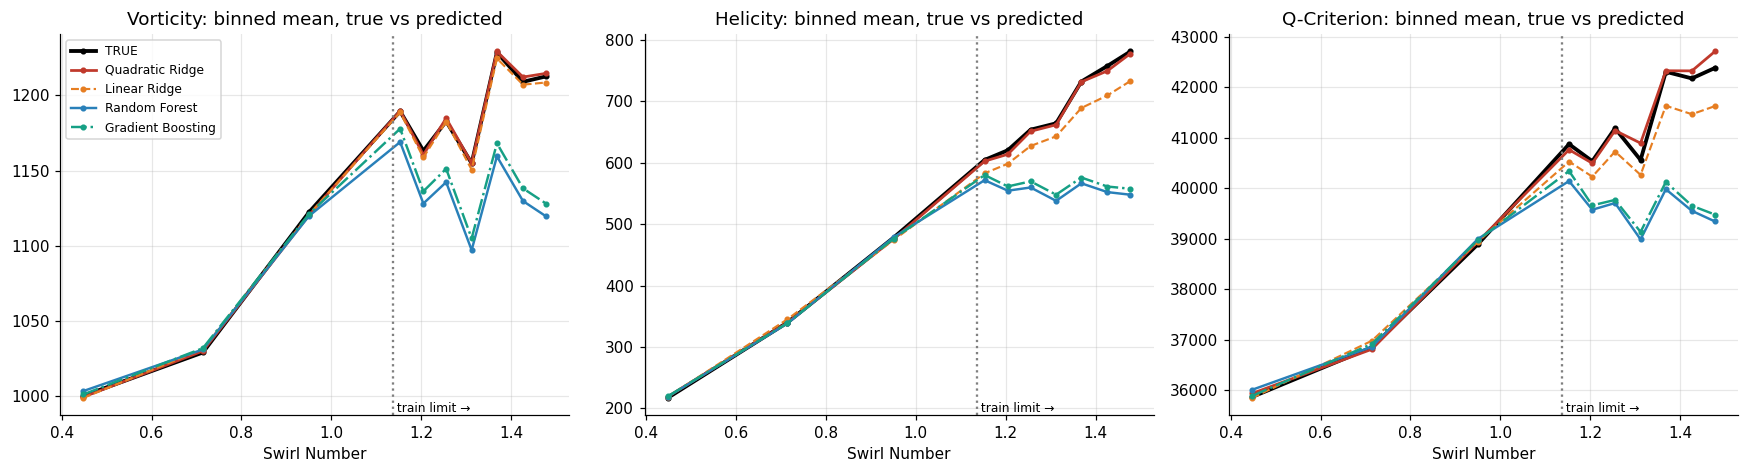

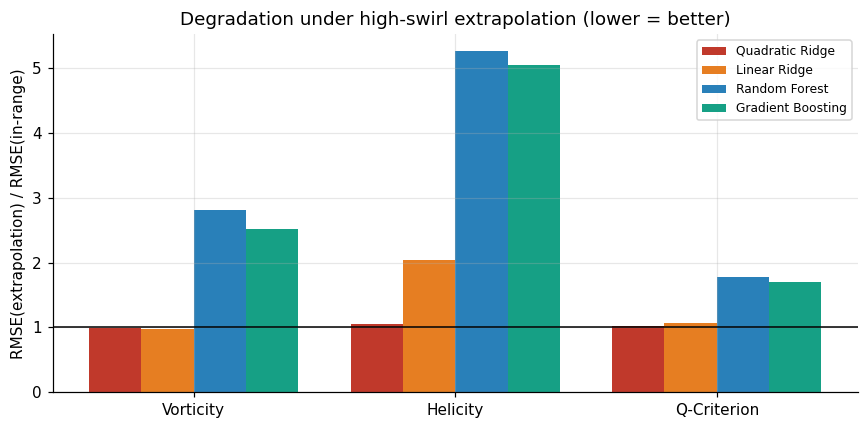

[18:17:54  +   346s] 💾 stage 'extrap' saved to Drive cache
Swirl training limit = 1.137   rows: {'train': 1053, 'cal': 348, 'test_in': 345, 'extrap': 754}


,target,model,Bias_extrapolation,Bias_in-range,R2_extrapolation,R2_in-range,RMSE_extrapolation,RMSE_in-range,RMSE_ratio_extrap_over_in
0,Helicity,Gradient Boosting,-125.7962,0.2180,-0.4456,0.9563,146.7841,29.1394,5.0373
1,Helicity,Linear Ridge,-33.1324,-0.1049,0.7176,0.9480,64.8725,31.7765,2.0415
2,Helicity,Quadratic Ridge,-3.8249,0.0733,0.9465,0.9629,28.2485,26.8544,1.0519
3,Helicity,Random Forest,-134.9107,0.3630,-0.6101,0.9553,154.9120,29.4709,5.2564
4,Q-Criterion,Gradient Boosting,-1728.9893,53.6590,0.5570,0.8699,2367.6708,1391.0907,1.7020
5,Q-Criterion,Linear Ridge,-513.2685,45.1423,0.8589,0.8937,1336.1600,1257.5461,1.0625
6,Q-Criterion,Quadratic Ridge,96.1155,21.2792,0.8594,0.8868,1333.8543,1297.5194,1.0280
7,Q-Criterion,Random Forest,-1851.1280,70.1432,0.5417,0.8765,2408.1450,1355.4482,1.7766
8,Vorticity,Gradient Boosting,-48.9349,0.7079,0.8949,0.9855,58.6094,23.3287,2.5123
9,Vorticity,Linear Ridge,-2.8726,-0.2019,0.9880,0.9891,19.7978,20.2122,0.9795


,target,coverage_in_range,coverage_extrapolation,nominal
0,Vorticity,0.910,0.902,0.9
1,Helicity,0.936,0.886,0.9
2,Q-Criterion,0.901,0.912,0.9


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 13 · HIGH-SWIRL EXTRAPOLATION TEST
#   Train only on rows with Swirl Number ≤ q(SWIRL_Q) of the training partition; evaluate on
#   (a) held-out in-range test rows  and  (b) EVERY dataset row above the threshold (never seen in training).
# ═══════════════════════════════════════════════════════════════════════════
if stage_done("extrap"):
    EXT = load_stage("extrap")
    show_saved("fig_extrapolation_binned", "fig_extrapolation_rmse_ratio")
else:
    thr = float(np.quantile(Xtr[:, SWIRL_J], SWIRL_Q))
    tr_lo = idx_tr[Xtr[:, SWIRL_J] <= thr]; cal_lo = idx_cal[Xcal[:, SWIRL_J] <= thr]; te_lo = idx_te[Xte[:, SWIRL_J] <= thr]
    hi_all = np.where(X[:, SWIRL_J] > thr)[0]
    log(f"Swirl threshold {thr:.3f}: train {len(tr_lo)} · cal {len(cal_lo)} · in-range test {len(te_lo)} · extrapolation rows {len(hi_all)}")
    rows, preds, cov_rows = [], {}, []
    for lab in LABS:
        for mname in EXTRAP_MODELS:
            m = make_model(mname).fit(X[tr_lo], Y[lab][tr_lo])
            p_in, p_hi = m.predict(X[te_lo]), m.predict(X[hi_all]); preds[(lab, mname)] = (p_in, p_hi)
            rin, rhi = reg_metrics(Y[lab][te_lo], p_in), reg_metrics(Y[lab][hi_all], p_hi)
            rows += [dict(target=lab, model=mname, regime="in-range", **rin), dict(target=lab, model=mname, regime="extrapolation", **rhi)]
            if mname == "Quadratic Ridge":
                q = conformal_q(np.abs(Y[lab][cal_lo] - m.predict(X[cal_lo])), ALPHA_CONF)
                cov_rows.append(dict(target=lab, coverage_in_range=float(np.mean(np.abs(Y[lab][te_lo] - p_in) <= q)),
                                     coverage_extrapolation=float(np.mean(np.abs(Y[lab][hi_all] - p_hi) <= q)), nominal=1 - ALPHA_CONF))
    met = pd.DataFrame(rows); cov = pd.DataFrame(cov_rows)
    wide = met.pivot_table(index=["target", "model"], columns="regime", values=["R2", "RMSE", "Bias"]); wide.columns = [f"{a}_{b}" for a, b in wide.columns]
    wide = wide.reset_index(); wide["RMSE_ratio_extrap_over_in"] = wide["RMSE_extrapolation"] / wide["RMSE_in-range"]
    save_table(met, "extrapolation_metrics_long"); save_table(wide, "extrapolation_metrics"); save_table(cov, "extrapolation_conformal_coverage")
    # binned truth-vs-prediction along swirl (rows never used in training)
    rows_b = np.r_[te_lo, hi_all]; sw = X[rows_b, SWIRL_J]; edges = np.quantile(sw, np.linspace(0, 1, 11)); bidx = np.clip(np.digitize(sw, edges[1:-1]), 0, 9)
    bin_rows = []
    for lab in LABS:
        for b in range(10):
            sel = bidx == b
            bin_rows.append(dict(target=lab, model="TRUE", bin=b, swirl_mean=sw[sel].mean(), value=Y[lab][rows_b][sel].mean()))
            for mname in EXTRAP_MODELS:
                pp = np.r_[preds[(lab, mname)][0], preds[(lab, mname)][1]]
                bin_rows.append(dict(target=lab, model=mname, bin=b, swirl_mean=sw[sel].mean(), value=pp[sel].mean()))
    binned = pd.DataFrame(bin_rows); save_table(binned, "extrapolation_binned")
    sty = {"TRUE": ("k", "-", 2.5), "Quadratic Ridge": ("#c0392b", "-", 1.8), "Linear Ridge": ("#e67e22", "--", 1.4), "Random Forest": ("#2980b9", "-", 1.6), "Gradient Boosting": ("#16a085", "-.", 1.6)}
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))
    for a_, lab in zip(ax, LABS):
        for mname in ["TRUE"] + EXTRAP_MODELS:
            d_ = binned[(binned.target == lab) & (binned.model == mname)]; c, ls, lw = sty.get(mname, ("m", "-", 1.2))
            a_.plot(d_.swirl_mean, d_.value, ls, color=c, lw=lw, marker="o", ms=3, label=mname)
        a_.axvline(thr, c="grey", ls=":"); a_.text(thr, a_.get_ylim()[0], " train limit →", va="bottom", fontsize=8); a_.set_xlabel("Swirl Number"); a_.set_title(f"{lab}: binned mean, true vs predicted")
    ax[0].legend(fontsize=8); savefig(fig, "fig_extrapolation_binned")
    fig, ax = plt.subplots(1, 1, figsize=(8, 4)); w = 0.8 / len(EXTRAP_MODELS)
    for k, mname in enumerate(EXTRAP_MODELS):
        s = wide[wide.model == mname].set_index("target").loc[LABS]; ax.bar(np.arange(len(LABS)) + k * w, s.RMSE_ratio_extrap_over_in, w, label=mname, color=sty[mname][0])
    ax.axhline(1, c="k", lw=1); ax.set_xticks(np.arange(len(LABS)) + 0.4 - w / 2); ax.set_xticklabels(LABS); ax.set_ylabel("RMSE(extrapolation) / RMSE(in-range)"); ax.legend(fontsize=8)
    ax.set_title("Degradation under high-swirl extrapolation (lower = better)"); savefig(fig, "fig_extrapolation_rmse_ratio")
    EXT = dict(thr=thr, n=dict(train=len(tr_lo), cal=len(cal_lo), test_in=len(te_lo), extrap=len(hi_all)), long=met, wide=wide, cov=cov, binned=binned)
    save_stage("extrap", EXT)

print(f"Swirl training limit = {EXT['thr']:.3f}   rows: {EXT['n']}")
display(EXT["wide"].round(4)); display(EXT["cov"].round(3))


## 14 · Polynomial vs tree comparison

[18:18:06  +   359s] poly-vs-tree Vorticity    Quadratic Ridge      0.0s
[18:18:12  +   364s] poly-vs-tree Vorticity    Random Forest        5.5s
[18:18:13  +   365s] poly-vs-tree Vorticity    Gradient Boosting    1.3s
[18:18:13  +   365s] poly-vs-tree Helicity     Quadratic Ridge      0.0s
[18:18:19  +   371s] poly-vs-tree Helicity     Random Forest        6.0s
[18:18:21  +   373s] poly-vs-tree Helicity     Gradient Boosting    1.5s
[18:18:21  +   373s] poly-vs-tree Q-Criterion  Quadratic Ridge      0.0s
[18:18:26  +   378s] poly-vs-tree Q-Criterion  Random Forest        5.5s
[18:18:28  +   380s] poly-vs-tree Q-Criterion  Gradient Boosting    1.3s


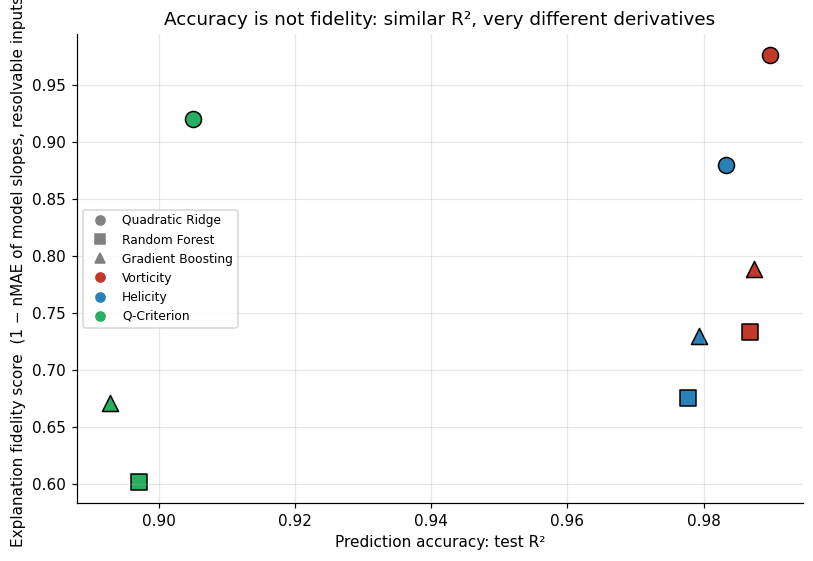

[18:18:28  +   380s] 💾 stage 'polytree' saved to Drive cache


,target,model,test_R2,fidelity_score,mean_nMAE_resolvable,sign_agree_resolvable,n_good,n_poor,mach_grade,mach_nMAE,R2_extrapolation,RMSE_ratio_extrap_over_in
0,Vorticity,Quadratic Ridge,0.9898,0.9763,0.0237,1.000,2,0,unresolved,1.0635,0.9868,0.9929
1,Vorticity,Random Forest,0.9869,0.7337,0.2663,1.000,2,0,unresolved,0.9399,0.8669,2.8117
2,Vorticity,Gradient Boosting,0.9875,0.7890,0.2110,1.000,2,0,unresolved,0.9985,0.8949,2.5123
3,Helicity,Quadratic Ridge,0.9832,0.8800,0.1200,1.000,2,0,unresolved,0.6998,0.9465,1.0519
4,Helicity,Random Forest,0.9777,0.6759,0.3241,0.993,1,0,unresolved,0.9317,-0.6101,5.2564
5,Helicity,Gradient Boosting,0.9793,0.7297,0.2703,0.995,1,0,unresolved,0.8535,-0.4456,5.0373
6,Q-Criterion,Quadratic Ridge,0.9050,0.9207,0.0793,1.000,2,0,unresolved,0.8454,0.8594,1.0280
7,Q-Criterion,Random Forest,0.8970,0.6021,0.3979,0.984,1,0,unresolved,0.9216,0.5417,1.7766
8,Q-Criterion,Gradient Boosting,0.8928,0.6712,0.3288,1.000,1,0,unresolved,0.9218,0.5570,1.7020


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 14 · POLYNOMIAL vs TREE COMPARISON — accuracy, extrapolation AND derivative fidelity
# ═══════════════════════════════════════════════════════════════════════════
PT_MODELS = ["Quadratic Ridge", "Random Forest", "Gradient Boosting"]
if stage_done("polytree"):
    PT = load_stage("polytree")
    show_saved("fig_accuracy_vs_fidelity")
else:
    rows = []
    for lab in LABS:
        for mname in PT_MODELS:
            t0 = time.time()
            m = MODELS[lab] if mname == SELECTED_MODEL else make_model(mname).fit(Xtr, Y[lab][idx_tr])
            r2 = reg_metrics(Y[lab][idx_te], m.predict(Xte))["R2"]
            G = fd_grad(m.predict, Xte, x_std)
            t = fidelity_table(G, DERIV["G_ref"][lab], DERIV["SE_ref"][lab], FEATS)
            mach_grade = t[t.feature == short(MACH_COL)].grade.iloc[0] if MACH_COL else "n/a"
            mach_nmae = float(t[t.feature == short(MACH_COL)].nMAE.iloc[0]) if MACH_COL else np.nan
            rows.append(dict(target=lab, model=mname, test_R2=r2, fidelity_score=fidelity_score(t), mean_nMAE_resolvable=float(t[t.resolvable].nMAE.mean()),
                             sign_agree_resolvable=float(t[t.resolvable].sign_agree.mean()), n_good=int((t.grade == "good").sum()), n_poor=int((t.grade == "poor").sum()),
                             mach_grade=mach_grade, mach_nMAE=mach_nmae))
            log(f"poly-vs-tree {lab:12s} {mname:18s} {time.time()-t0:5.1f}s")
    pt = pd.DataFrame(rows); save_table(pt, "polynomial_vs_tree")
    ex = EXT["wide"][EXT["wide"].model.isin(PT_MODELS)][["target", "model", "R2_extrapolation", "RMSE_ratio_extrap_over_in"]]
    pt_all = pt.merge(ex, on=["target", "model"], how="left"); save_table(pt_all, "polynomial_vs_tree_with_extrapolation")
    fig, ax = plt.subplots(1, 1, figsize=(7.5, 5.2)); mk = {"Quadratic Ridge": "o", "Random Forest": "s", "Gradient Boosting": "^"}; cl = dict(zip(LABS, ["#c0392b", "#2980b9", "#27ae60"]))
    for r in pt.itertuples(): ax.scatter(r.test_R2, r.fidelity_score, marker=mk[r.model], color=cl[r.target], s=110, edgecolor="k")
    ax.set_xlabel("Prediction accuracy: test R²"); ax.set_ylabel("Explanation fidelity score  (1 − nMAE of model slopes, resolvable inputs)")
    from matplotlib.lines import Line2D
    ax.legend(handles=[Line2D([], [], marker=mk[m], ls="", color="grey", label=m) for m in PT_MODELS] + [Line2D([], [], marker="o", ls="", color=cl[l], label=l) for l in LABS], fontsize=8)
    ax.set_title("Accuracy is not fidelity: similar R², very different derivatives"); savefig(fig, "fig_accuracy_vs_fidelity")
    PT = dict(table=pt_all)
    save_stage("polytree", PT)

display(PT["table"].round(4))


## 15 · FINAL FINDING & report

## 16 · Zip + download
Results are already in Drive; this cell also zips `results/`, `models/` and the dataset into `vortex_tube_results.zip` and triggers the browser download.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 16 · SAVE TO DRIVE + ZIP + DOWNLOAD
# ═══════════════════════════════════════════════════════════════════════════
ZIP_PATH = BASE / "vortex_tube_results.zip"
if ZIP_PATH.exists(): ZIP_PATH.unlink()
with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as z:
    for root in (BASE / "results", BASE / "models"):
        for f in sorted(root.rglob("*")):
            if f.is_file(): z.write(f, f.relative_to(BASE))
    z.write(DATA_PATH, "data/dataset.csv")
with zipfile.ZipFile(ZIP_PATH) as z:
    names = z.namelist()
print(f"📦 {ZIP_PATH}  ({ZIP_PATH.stat().st_size/1e6:.1f} MB, {len(names)} files)")
print("   tables :", sum(n.startswith("results/tables") for n in names), "| figures:", sum(n.startswith("results/figures") for n in names),
      "| models:", sum(n.startswith("models") for n in names), "| report files:", sum(n.startswith("results/report") for n in names))
print(f"☁️  Everything is also stored permanently in Google Drive → {BASE}")
print(f"⏱️  Total runtime this session: {(time.time()-T0)/60:.1f} min")
if IN_COLAB:
    files.download(str(ZIP_PATH))
else:
    print("(not in Colab: download skipped)")


📦 /content/drive/MyDrive/vortex_tube_helicity/vortex_tube_results.zip  (2.5 MB, 56 files)
   tables : 34 | figures: 14 | models: 3 | report files: 4
☁️  Everything is also stored permanently in Google Drive → /content/drive/MyDrive/vortex_tube_helicity
⏱️  Total runtime this session: 7.1 min


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>